In [16]:

# =========================================================
# PHASE 1 — NVDA FOUNDATION PIPELINE
# =========================================================
# Scope:
# 1) Load and clean HistoricalData_1754061510662.csv
# 2) Create log price, simple return, log return, squared return, realized volatility
# 3) EDA: price, return distribution, rolling statistics
# 4) Volatility analysis: realized volatility, regimes, squared returns
# 5) ACF/PACF and decomposition
# 6) Stationarity tests: ADF and KPSS
# 7) Classical baselines: Trend, ARIMA, ARMA, optional GARCH

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox

try:
    from arch import arch_model
    ARCH_AVAILABLE = True
except ImportError:
    ARCH_AVAILABLE = False
    print("Package 'arch' is not installed. GARCH section will be skipped.")
    print("To enable GARCH: pip install arch")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

DATA_PATH = "HistoricalData_1754061510662.csv"
TEST_SIZE = 0.20
RANDOM_SEED = 42

OUTPUT_DIR = Path("outputs_phase1")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DATA_DIR = OUTPUT_DIR / "data"

for folder in [FIG_DIR, TABLE_DIR, DATA_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

def save_current_fig(name: str):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")


In [17]:
# =========================================================
# 1. LOAD AND CLEAN DATA
# =========================================================
def load_and_clean_data(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path)
    print("Initial columns:", df.columns.tolist())

    df.columns = df.columns.str.strip()
    if "Close/Last" in df.columns:
        df = df.rename(columns={"Close/Last": "Close"})

    numeric_cols = ["Close", "Open", "High", "Low", "Volume"]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = (
                df[col].astype(str)
                .str.replace("$", "", regex=False)
                .str.replace(",", "", regex=False)
            )
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "Date" not in df.columns:
        raise ValueError("Date column not found.")


    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date", "Close"])
    df = df.sort_values("Date").set_index("Date")

    keep_cols = [col for col in ["Close", "Open", "High", "Low", "Volume"] if col in df.columns]
    df = df[keep_cols].copy()

    print("Data cleaned successfully.")
    print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
    print(f"Rows: {len(df)}")
    return df

def create_time_series_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["log_price"] = np.log(out["Close"])
    out["simple_return"] = out["Close"].pct_change()
    out["log_return"] = np.log(out["Close"] / out["Close"].shift(1))
    out["squared_return"] = out["log_return"] ** 2

    out["rolling_mean_20"] = out["Close"].rolling(window=20).mean()
    out["rolling_std_20"] = out["Close"].rolling(window=20).std()
    out["rolling_return_mean_20"] = out["log_return"].rolling(window=20).mean()
    out["rolling_return_std_20"] = out["log_return"].rolling(window=20).std()
    out["realized_vol_21"] = out["log_return"].rolling(window=21).std() * np.sqrt(252)

    if "Volume" in out.columns:
        out["volume_change"] = out["Volume"].pct_change()

    return out.dropna().copy()

raw_df = load_and_clean_data(DATA_PATH)
df = create_time_series_features(raw_df)

clean_path = DATA_DIR / "cleaned_nvda_phase1.csv"
df.to_csv(clean_path)
print(f"Cleaned data saved to: {clean_path}")
display(df.head())

Initial columns: ['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']
Data cleaned successfully.
Date range: 2015-07-31 to 2025-07-31
Rows: 2515
Cleaned data saved to: outputs_phase1\data\cleaned_nvda_phase1.csv


,Close,Open,High,Low,Volume,log_price,simple_return,log_return,squared_return,rolling_mean_20,rolling_std_20,rolling_return_mean_20,rolling_return_std_20,realized_vol_21,volume_change
Date,,,,,,,,,,,,,,,
2015-08-31,0.5620,0.5655,0.5695,0.5596,219346440,-0.576253,-0.011086,-0.011148,0.000124,0.557910,0.031303,0.005130,0.036744,0.569931,-0.316518
2015-09-01,0.5390,0.5457,0.5550,0.5350,353408800,-0.618040,-0.040925,-0.041786,0.001746,0.559395,0.029530,0.002834,0.038215,0.591294,0.611190
2015-09-02,0.5553,0.5537,0.5555,0.5445,344038320,-0.588247,0.030241,0.029793,0.000888,0.561435,0.027613,0.003816,0.038662,0.598606,-0.026515
2015-09-03,0.5567,0.5635,0.5663,0.5558,262557520,-0.585729,0.002521,0.002518,0.000006,0.563710,0.025007,0.004263,0.038589,0.598220,-0.236836
2015-09-04,0.5438,0.5473,0.5560,0.5435,287957800,-0.609174,-0.023172,-0.023445,0.000550,0.562175,0.025251,-0.002746,0.028495,0.604737,0.096742


In [18]:
# =========================================================
# 2. DESCRIPTIVE STATISTICS
# =========================================================
summary_cols = ["Close", "log_price", "simple_return", "log_return", "squared_return", "realized_vol_21"]
if "Volume" in df.columns:
    summary_cols.insert(1, "Volume")

descriptive_stats = df[summary_cols].describe().T.round(6)
descriptive_stats.to_csv(TABLE_DIR / "descriptive_statistics.csv")
display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max
Close,2494.0,2.862829e+01,4.137862e+01,5.390000e-01,4.134400e+00,1.138790e+01,2.739575e+01,1.792700e+02
Volume,2494.0,4.651911e+08,2.535301e+08,5.244924e+07,3.012633e+08,4.137470e+08,5.628425e+08,3.688132e+09
log_price,2494.0,2.383711e+00,1.457379e+00,-6.180400e-01,1.419342e+00,2.432541e+00,3.310388e+00,5.188893e+00
simple_return,2494.0,2.799000e-03,3.152200e-02,-1.875570e-01,-1.298900e-02,2.818000e-03,1.860500e-02,2.980580e-01
log_return,2494.0,2.304000e-03,3.131000e-02,-2.077090e-01,-1.307400e-02,2.814000e-03,1.843400e-02,2.608690e-01
squared_return,2494.0,9.850000e-04,2.901000e-03,0.000000e+00,5.200000e-05,2.620000e-04,9.150000e-04,6.805300e-02
realized_vol_21,2494.0,4.598000e-01,1.942060e-01,1.397980e-01,3.193020e-01,4.050650e-01,5.656310e-01,1.393026e+00


Saved: outputs_phase1\figures\01_close_price_over_time.png


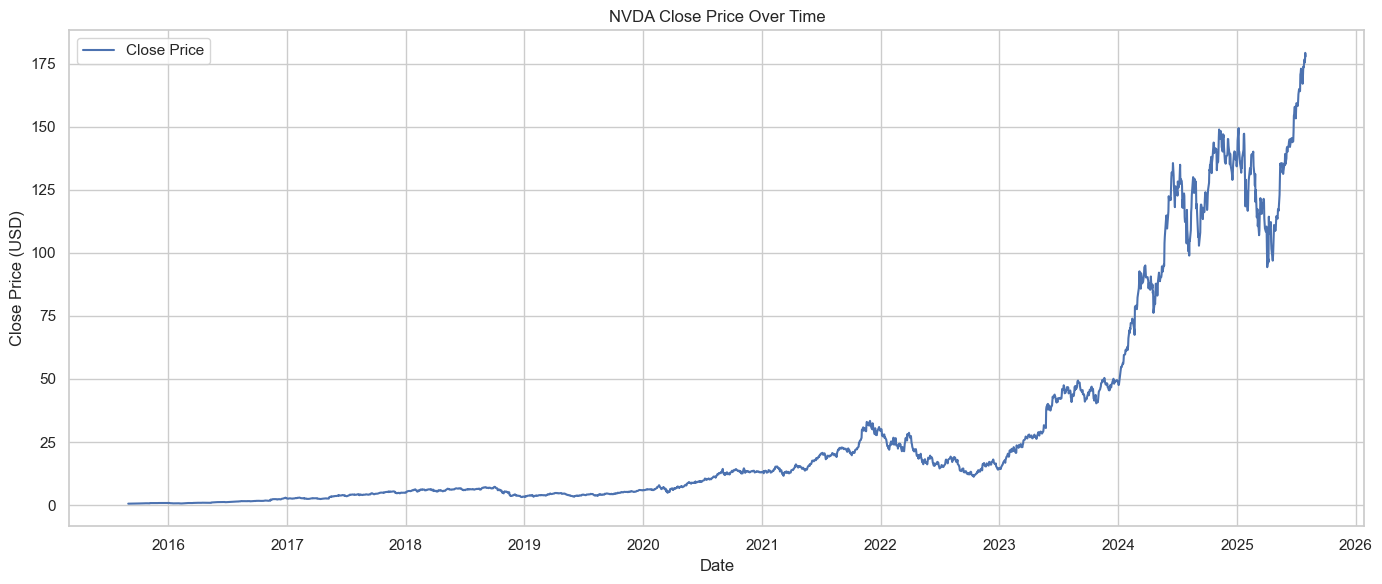

Saved: outputs_phase1\figures\02_log_return_distribution.png


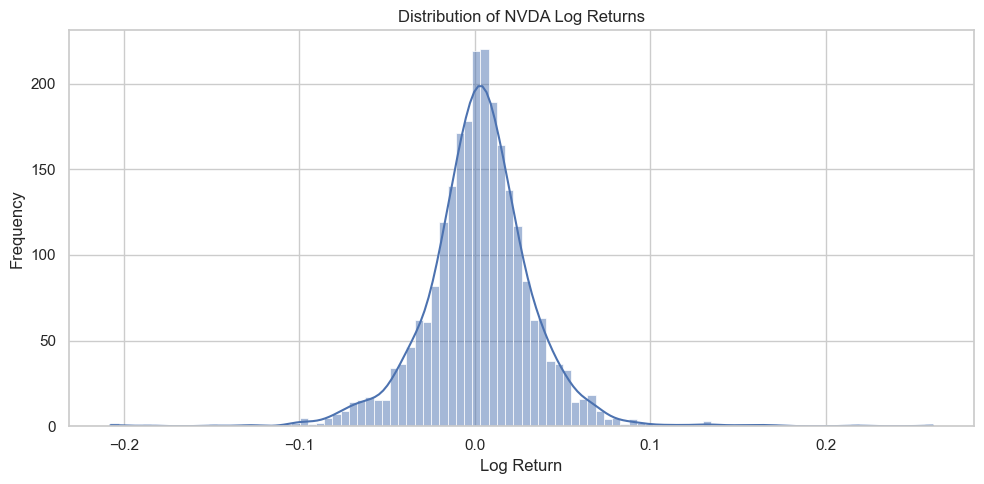

Saved: outputs_phase1\figures\03_price_rolling_statistics.png


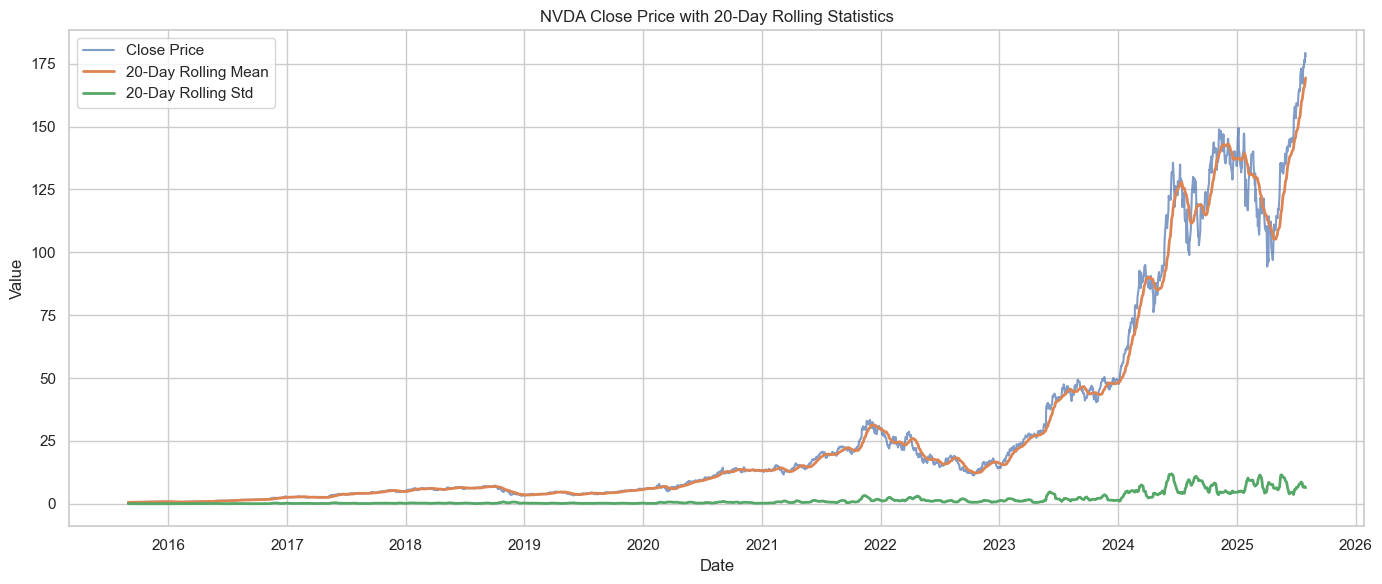

Saved: outputs_phase1\figures\04_return_rolling_statistics.png


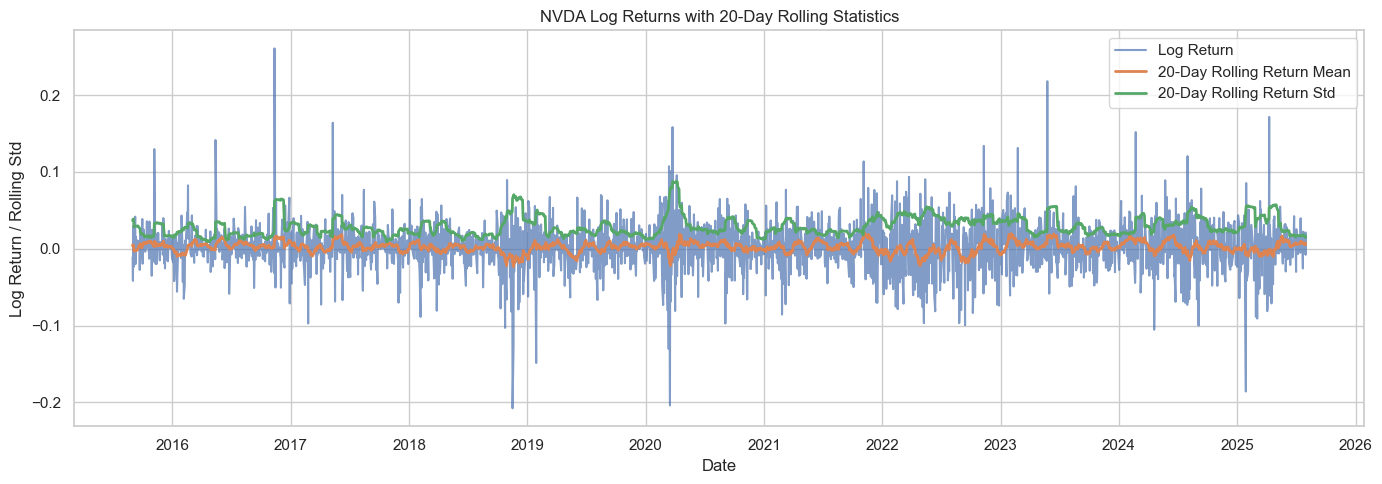

In [19]:
# =========================================================
# 3. EDA PLOTS
# =========================================================
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], label="Close Price")
plt.title("NVDA Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
save_current_fig("01_close_price_over_time.png")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df["log_return"], bins=100, kde=True)
plt.title("Distribution of NVDA Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
save_current_fig("02_log_return_distribution.png")
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], label="Close Price", alpha=0.7)
plt.plot(df.index, df["rolling_mean_20"], label="20-Day Rolling Mean", linewidth=2)
plt.plot(df.index, df["rolling_std_20"], label="20-Day Rolling Std", linewidth=2)
plt.title("NVDA Close Price with 20-Day Rolling Statistics")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
save_current_fig("03_price_rolling_statistics.png")
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["log_return"], label="Log Return", alpha=0.7)
plt.plot(df.index, df["rolling_return_mean_20"], label="20-Day Rolling Return Mean", linewidth=2)
plt.plot(df.index, df["rolling_return_std_20"], label="20-Day Rolling Return Std", linewidth=2)
plt.title("NVDA Log Returns with 20-Day Rolling Statistics")
plt.xlabel("Date")
plt.ylabel("Log Return / Rolling Std")
plt.legend()
save_current_fig("04_return_rolling_statistics.png")
plt.show()

Saved: outputs_phase1\figures\05_realized_volatility.png


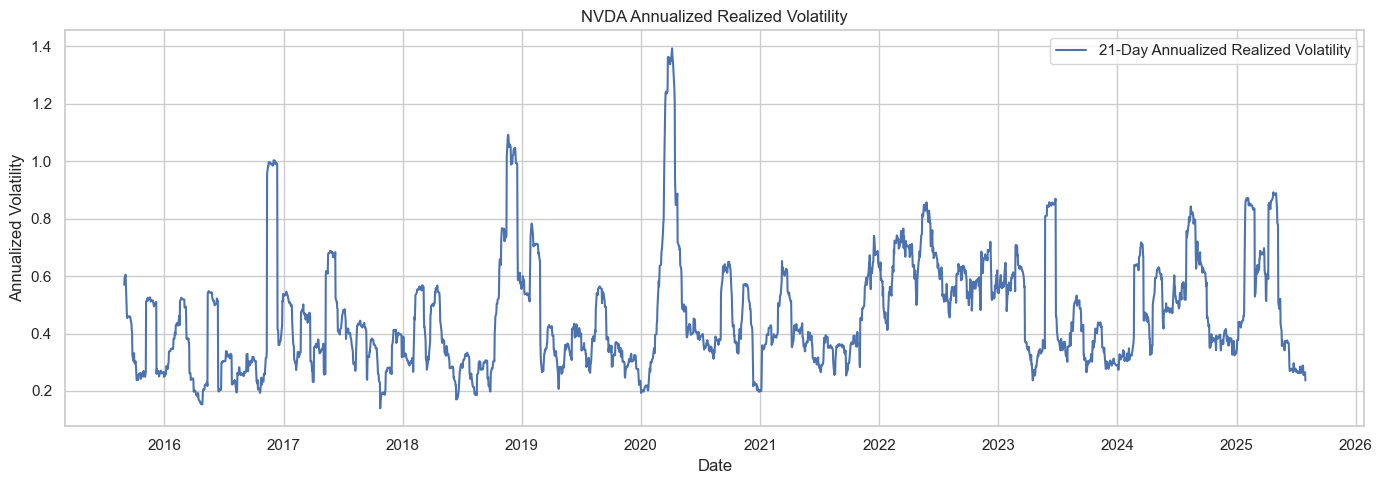

Saved: outputs_phase1\figures\06_volatility_regimes.png


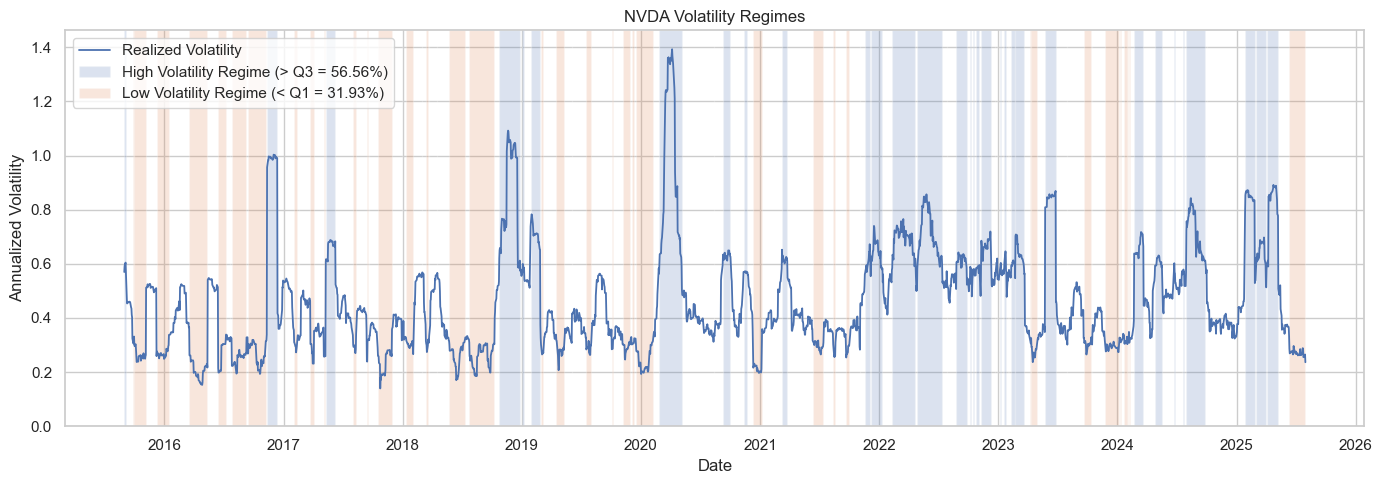

Saved: outputs_phase1\figures\07_squared_returns_volatility_clustering.png


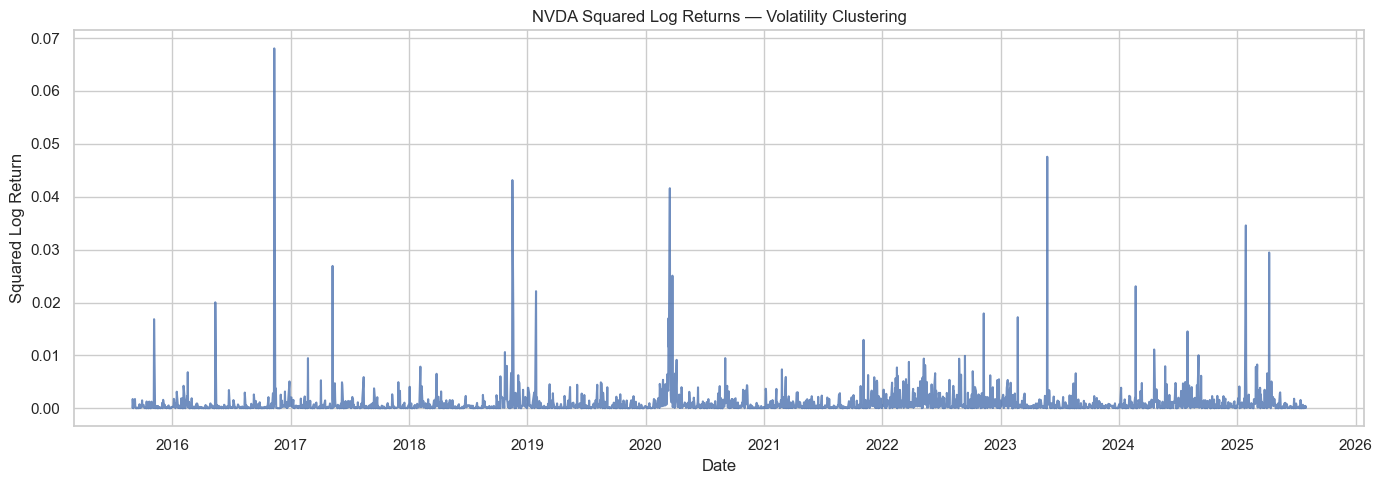

,Metric,Value
0,Q1 Realized Volatility,0.319302
1,Q3 Realized Volatility,0.565631
2,Mean Realized Volatility,0.459800
3,Max Realized Volatility,1.393026


In [20]:
# =========================================================
# 4. VOLATILITY ANALYSIS
# =========================================================
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["realized_vol_21"], label="21-Day Annualized Realized Volatility")
plt.title("NVDA Annualized Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
save_current_fig("05_realized_volatility.png")
plt.show()

vol_q25 = df["realized_vol_21"].quantile(0.25)
vol_q75 = df["realized_vol_21"].quantile(0.75)

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["realized_vol_21"], label="Realized Volatility", linewidth=1.3)
plt.fill_between(
    df.index, 0, df["realized_vol_21"].max() * 1.05,
    where=df["realized_vol_21"] > vol_q75,
    alpha=0.2,
    label=f"High Volatility Regime (> Q3 = {vol_q75:.2%})"
)
plt.fill_between(
    df.index, 0, df["realized_vol_21"].max() * 1.05,
    where=df["realized_vol_21"] < vol_q25,
    alpha=0.2,
    label=f"Low Volatility Regime (< Q1 = {vol_q25:.2%})"
)
plt.title("NVDA Volatility Regimes")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.ylim(0, df["realized_vol_21"].max() * 1.05)
plt.legend(loc="upper left")
save_current_fig("06_volatility_regimes.png")
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["squared_return"], alpha=0.8)
plt.title("NVDA Squared Log Returns — Volatility Clustering")
plt.xlabel("Date")
plt.ylabel("Squared Log Return")
save_current_fig("07_squared_returns_volatility_clustering.png")
plt.show()

vol_summary = pd.DataFrame({
    "Metric": ["Q1 Realized Volatility", "Q3 Realized Volatility", "Mean Realized Volatility", "Max Realized Volatility"],
    "Value": [vol_q25, vol_q75, df["realized_vol_21"].mean(), df["realized_vol_21"].max()]
})
vol_summary.to_csv(TABLE_DIR / "volatility_summary.csv", index=False)
display(vol_summary)

Saved: outputs_phase1\figures\08_acf_pacf_close_price.png


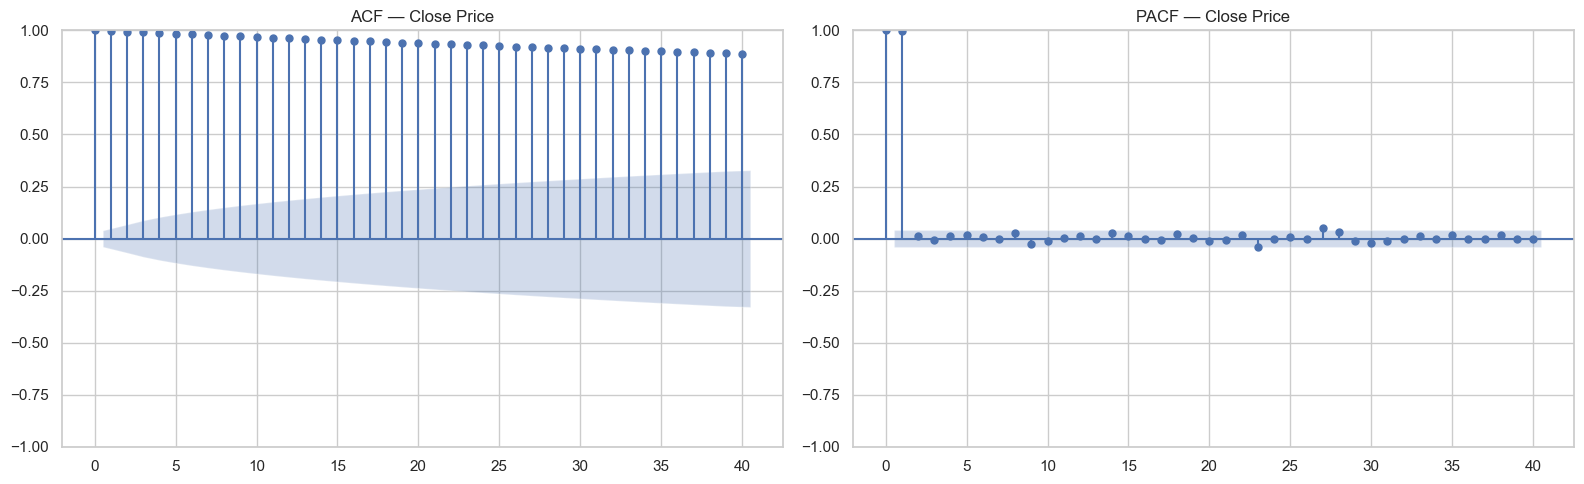

Saved: outputs_phase1\figures\09_acf_pacf_log_returns.png


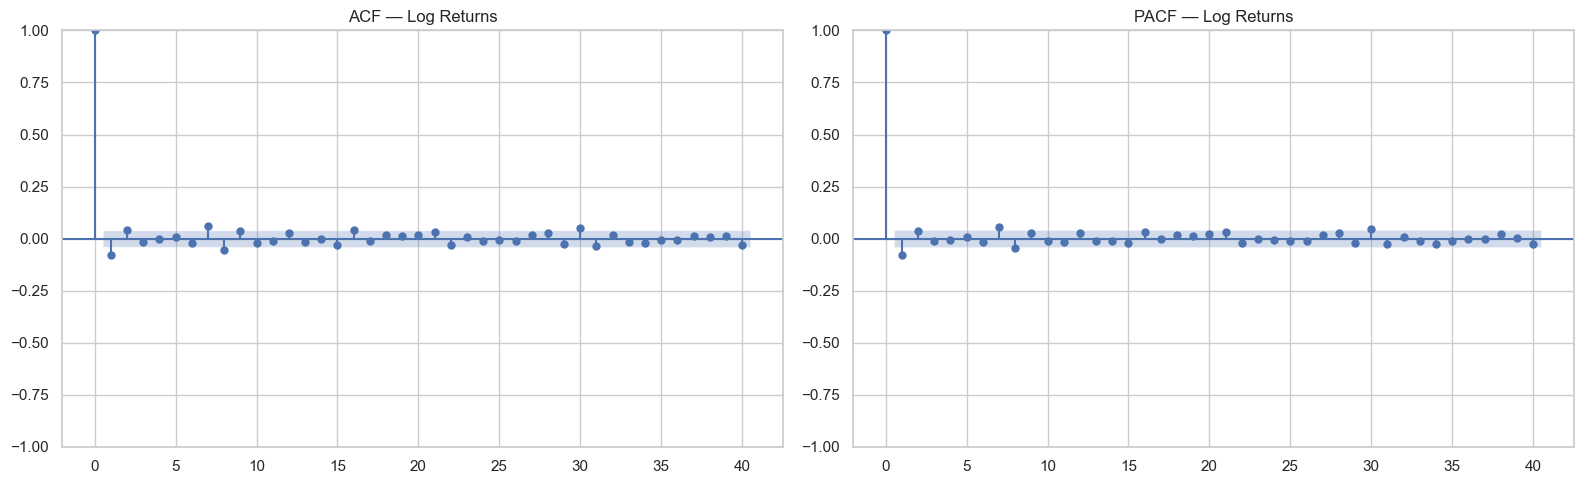

Saved: outputs_phase1\figures\10_acf_pacf_squared_returns.png


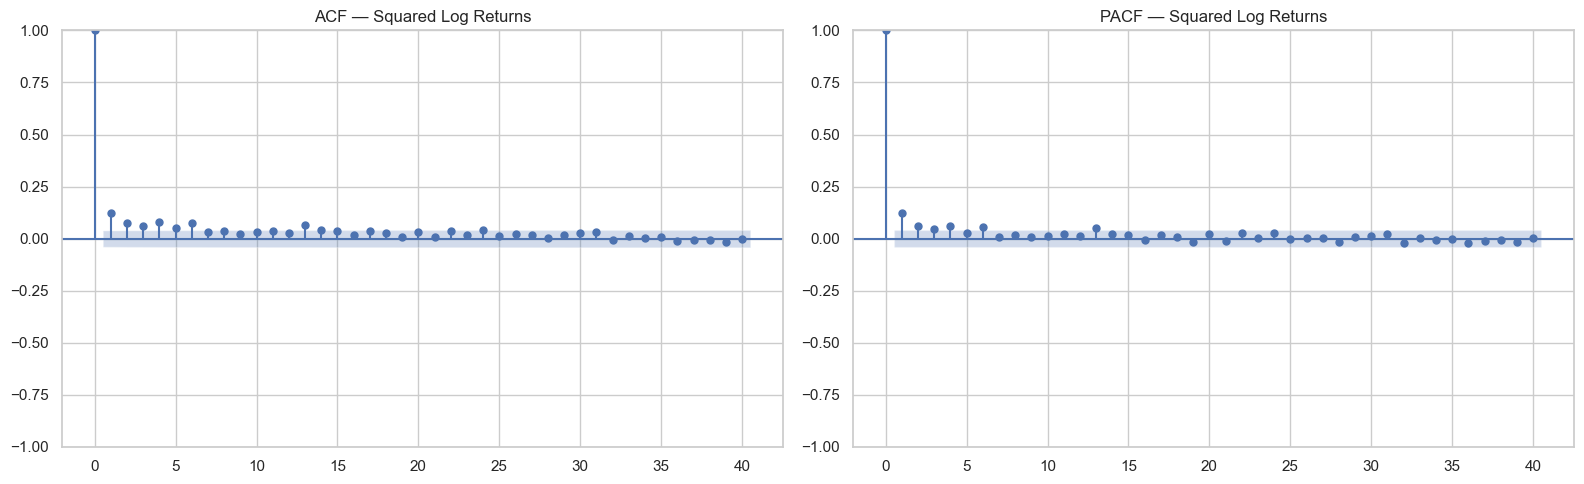

Saved: outputs_phase1\figures\11_time_series_decomposition.png


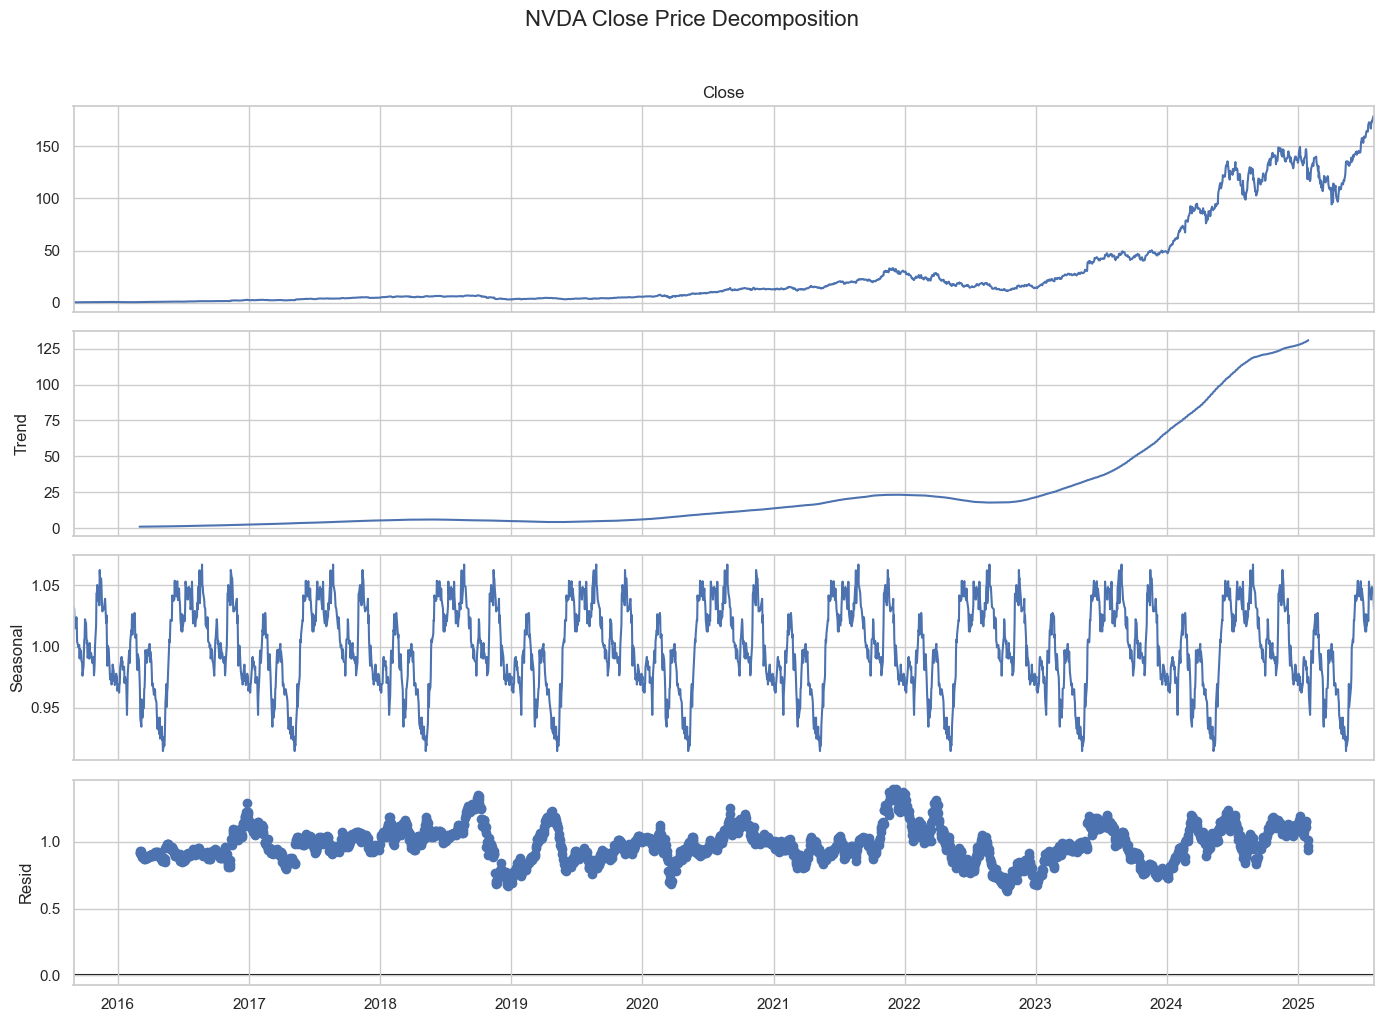

In [21]:
# =========================================================
# 5. ACF / PACF AND DECOMPOSITION
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df["Close"], ax=axes[0], lags=40)
axes[0].set_title("ACF — Close Price")
plot_pacf(df["Close"], ax=axes[1], lags=40, method="ywm")
axes[1].set_title("PACF — Close Price")
save_current_fig("08_acf_pacf_close_price.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df["log_return"], ax=axes[0], lags=40)
axes[0].set_title("ACF — Log Returns")
plot_pacf(df["log_return"], ax=axes[1], lags=40, method="ywm")
axes[1].set_title("PACF — Log Returns")
save_current_fig("09_acf_pacf_log_returns.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df["squared_return"], ax=axes[0], lags=40)
axes[0].set_title("ACF — Squared Log Returns")
plot_pacf(df["squared_return"], ax=axes[1], lags=40, method="ywm")
axes[1].set_title("PACF — Squared Log Returns")
save_current_fig("10_acf_pacf_squared_returns.png")
plt.show()

if len(df) >= 2 * 252:
    decomposition = seasonal_decompose(df["Close"], model="multiplicative", period=252)
    fig = decomposition.plot()
    fig.set_size_inches(14, 10)
    plt.suptitle("NVDA Close Price Decomposition", fontsize=16, y=1.02)
    save_current_fig("11_time_series_decomposition.png")
    plt.show()
else:
    print("Not enough data for stable annual decomposition with period=252.")

In [22]:
# =========================================================
# 6. STATIONARITY ANALYSIS
# =========================================================
def run_adf(series: pd.Series, name: str) -> dict:
    series = series.dropna()
    result = adfuller(series, autolag="AIC")
    return {
        "Series": name,
        "Test": "ADF",
        "Statistic": result[0],
        "p_value": result[1],
        "Lags": result[2],
        "Observation_Count": result[3],
        "Conclusion_5pct": "Stationary" if result[1] < 0.05 else "Non-stationary"
    }

def run_kpss(series: pd.Series, name: str, regression: str = "c") -> dict:
    series = series.dropna()
    result = kpss(series, regression=regression, nlags="auto")
    return {
        "Series": name,
        "Test": "KPSS",
        "Statistic": result[0],
        "p_value": result[1],
        "Lags": result[2],
        "Observation_Count": len(series),
        "Conclusion_5pct": "Non-stationary" if result[1] < 0.05 else "Stationary"
    }

stationarity_rows = []
series_map = {
    "Close Price": df["Close"],
    "Log Price": df["log_price"],
    "Log Return": df["log_return"],
    "First Difference of Close Price": df["Close"].diff()
}

for name, series in series_map.items():
    try:
        stationarity_rows.append(run_adf(series, name))
    except Exception as e:
        print(f"ADF failed for {name}: {e}")
    try:
        stationarity_rows.append(run_kpss(series, name))
    except Exception as e:
        print(f"KPSS failed for {name}: {e}")

stationarity_results = pd.DataFrame(stationarity_rows)
stationarity_results.to_csv(TABLE_DIR / "stationarity_tests.csv", index=False)
display(stationarity_results)

,Series,Test,Statistic,p_value,Lags,Observation_Count,Conclusion_5pct
0,Close Price,ADF,2.504850,9.990514e-01,27,2466,Non-stationary
1,Close Price,KPSS,5.165108,1.000000e-02,30,2494,Non-stationary
2,Log Price,ADF,-0.735020,8.374689e-01,8,2485,Non-stationary
3,Log Price,KPSS,7.438217,1.000000e-02,30,2494,Non-stationary
4,Log Return,ADF,-17.826713,3.145177e-30,7,2486,Stationary
5,Log Return,KPSS,0.093899,1.000000e-01,2,2494,Stationary
6,First Difference of Close Price,ADF,-8.118205,1.175275e-12,27,2465,Stationary
7,First Difference of Close Price,KPSS,0.879868,1.000000e-02,18,2493,Non-stationary


In [23]:
# =========================================================
# 7. CLASSICAL BASELINE HELPERS
# =========================================================
def temporal_train_val_test_split(
    data: pd.DataFrame,
    test_size: float = 0.20,
    val_size: float = 0.20
):
    """
    Chronological split:
    - Test is the final test_size portion.
    - Validation is the final val_size portion of the remaining train/validation block.
    - Train is the earliest block.

    Example with test_size=0.20 and val_size=0.20:
    Train ≈ 64%, Validation ≈ 16%, Test ≈ 20%.
    """
    test_start = int(len(data) * (1 - test_size))

    train_val = data.iloc[:test_start].copy()
    test = data.iloc[test_start:].copy()

    val_start = int(len(train_val) * (1 - val_size))

    train = train_val.iloc[:val_start].copy()
    val = train_val.iloc[val_start:].copy()

    return train, val, test

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_forecast(model_name: str, y_true, y_pred) -> dict:
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred)
    }

def trend_forecast(train_close: pd.Series, test_len: int) -> np.ndarray:
    x_train = np.arange(len(train_close)).reshape(-1, 1)
    x_test = np.arange(len(train_close), len(train_close) + test_len).reshape(-1, 1)

    model = LinearRegression()
    model.fit(x_train, np.log(train_close.values))
    pred_log = model.predict(x_test)
    return np.exp(pred_log)

def arima_select_and_forecast(series: pd.Series, test_len: int, candidates, label: str):
    rows = []
    best_fit = None
    best_order = None
    best_aic = np.inf

    for order in candidates:
        try:
            fitted = ARIMA(series, order=order).fit()
            rows.append({
                "Series": label,
                "Order": order,
                "AIC": fitted.aic,
                "BIC": fitted.bic
            })
            if fitted.aic < best_aic:
                best_fit = fitted
                best_order = order
                best_aic = fitted.aic
        except Exception as e:
            print(f"ARIMA{order} failed for {label}: {e}")

    results_df = pd.DataFrame(rows)
    if results_df.empty or best_fit is None:
        raise ValueError(f"No ARIMA model could be fitted for {label}.")

    results_df = results_df.sort_values(["AIC", "BIC"]).reset_index(drop=True)
    forecast_res = best_fit.get_forecast(steps=test_len)
    forecast_mean = forecast_res.predicted_mean
    conf_int = forecast_res.conf_int(alpha=0.05)
    return results_df, best_order, forecast_mean, conf_int, best_fit

def arma_select_and_forecast(train_returns: pd.Series, test_len: int, candidates):
    rows = []
    best_fit = None
    best_order = None
    best_aic = np.inf

    for p, q in candidates:
        try:
            fitted = ARIMA(train_returns, order=(p, 0, q)).fit()
            rows.append({
                "Model": f"ARMA({p},{q})",
                "Order": (p, q),
                "AIC": fitted.aic,
                "BIC": fitted.bic
            })
            if fitted.aic < best_aic:
                best_fit = fitted
                best_order = (p, q)
                best_aic = fitted.aic
        except Exception as e:
            print(f"ARMA({p},{q}) failed: {e}")

    results_df = pd.DataFrame(rows)
    if results_df.empty or best_fit is None:
        raise ValueError("No ARMA model could be fitted for returns.")

    results_df = results_df.sort_values(["AIC", "BIC"]).reset_index(drop=True)
    forecast = best_fit.forecast(steps=test_len)
    residuals = best_fit.resid
    lb_resid = acorr_ljungbox(residuals, lags=[10], return_df=True)
    diagnostics = {
        "Best ARMA Order": best_order,
        "Ljung-Box p-value (lag 10)": float(lb_resid["lb_pvalue"].iloc[0])
    }
    return results_df, best_order, forecast, residuals, diagnostics, best_fit

VALIDATION_SIZE = 0.20

train, val, test = temporal_train_val_test_split(df, TEST_SIZE, VALIDATION_SIZE)

print(f"Total observations     : {len(df)}")
print(f"Train observations     : {len(train)}")
print(f"Validation observations: {len(val)}")
print(f"Test observations      : {len(test)}")
print(f"Train range     : {train.index.min().date()} to {train.index.max().date()}")
print(f"Validation range: {val.index.min().date()} to {val.index.max().date()}")
print(f"Test range      : {test.index.min().date()} to {test.index.max().date()}")

Total observations     : 2494
Train observations     : 1596
Validation observations: 399
Test observations      : 499
Train range     : 2015-08-31 to 2021-12-30
Validation range: 2021-12-31 to 2023-08-03
Test range      : 2023-08-04 to 2025-07-31


ARIMA selection on Close price:


,Series,Order,AIC,BIC
0,Close Price,"(2, 1, 2)",534.238996,561.112141
1,Close Price,"(4, 1, 1)",554.470405,586.718179
2,Close Price,"(3, 1, 1)",559.701852,586.574997
3,Close Price,"(3, 1, 2)",559.861310,592.109084
4,Close Price,"(2, 1, 1)",564.698348,586.196864
5,Close Price,"(1, 1, 2)",569.147827,590.646343
6,Close Price,"(1, 1, 1)",579.871357,595.995244


ARIMA selection on Log price:


,Series,Order,AIC,BIC
0,Log Price,"(1, 1, 2)",-6755.770972,-6734.272456
1,Log Price,"(2, 1, 1)",-6754.995861,-6733.497345
2,Log Price,"(2, 1, 2)",-6754.445364,-6727.572218
3,Log Price,"(3, 1, 1)",-6754.258685,-6727.385540
4,Log Price,"(1, 1, 1)",-6752.671249,-6736.547362
5,Log Price,"(4, 1, 1)",-6752.267846,-6720.020072
6,Log Price,"(3, 1, 2)",-6752.258284,-6720.010510


Price forecasting evaluation — sorted by validation RMSE:


,Model,MAE,RMSE,MAPE,Validation_MAE,Validation_RMSE,Validation_MAPE,Selected_By,Selected_Model
0,"ARIMA Log Price (1, 1, 2)",72.640946,81.902666,65.080943,9.866744,11.078948,53.860813,Validation_RMSE,True
1,"ARIMA Price (2, 1, 2)",72.537002,81.810490,64.958069,9.941508,11.141917,54.303439,Validation_RMSE,False
2,Trend (Log-Linear),23.940919,29.140033,21.906140,11.519447,13.353094,64.574001,Validation_RMSE,False


Saved: outputs_phase1\figures\12_classical_price_forecast_comparison.png


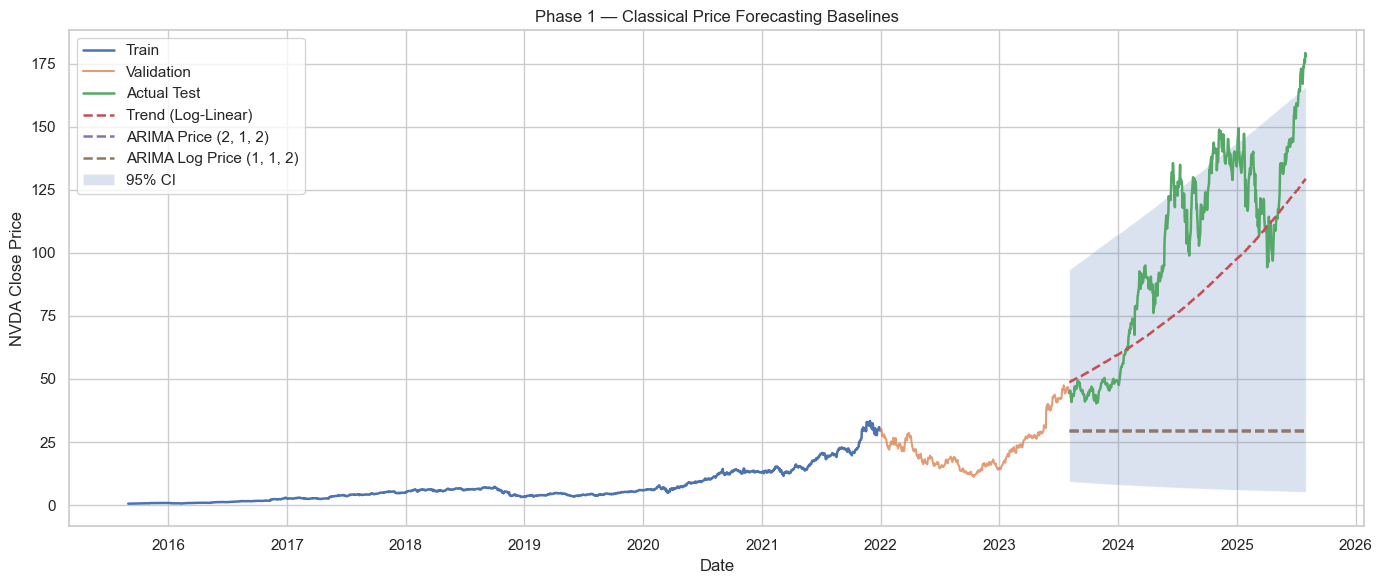

Selected price baseline by validation RMSE: ARIMA Log Price (1, 1, 2)


In [24]:
# =========================================================
# 8. PRICE FORECASTING BASELINES — VALIDATION-BASED SELECTION
# =========================================================

price_candidates = [
    (1, 1, 1),
    (1, 1, 2),
    (2, 1, 1),
    (2, 1, 2),
    (3, 1, 1),
    (3, 1, 2),
    (4, 1, 1)
]

# Forecast validation + test in one continuous horizon from the training endpoint.
val_test_len = len(val) + len(test)

# 1. Trend baseline
trend_all = trend_forecast(train["Close"], val_test_len)
trend_val = trend_all[:len(val)]
trend_test = trend_all[len(val):]

# 2. ARIMA on Close price
price_sel_df, best_price_order, price_forecast_all, price_ci_all, price_fit = arima_select_and_forecast(
    train["Close"], val_test_len, price_candidates, "Close Price"
)
price_val = price_forecast_all.iloc[:len(val)] if hasattr(price_forecast_all, "iloc") else price_forecast_all[:len(val)]
price_test = price_forecast_all.iloc[len(val):] if hasattr(price_forecast_all, "iloc") else price_forecast_all[len(val):]

# 3. ARIMA on log price
log_sel_df, best_log_order, log_forecast_all, log_ci_all, log_fit = arima_select_and_forecast(
    train["log_price"], val_test_len, price_candidates, "Log Price"
)
log_price_all = np.exp(log_forecast_all)
log_price_val = log_price_all.iloc[:len(val)] if hasattr(log_price_all, "iloc") else log_price_all[:len(val)]
log_price_test = log_price_all.iloc[len(val):] if hasattr(log_price_all, "iloc") else log_price_all[len(val):]

# Validation metrics: used for model selection.
price_val_eval = pd.DataFrame([
    evaluate_forecast("Trend (Log-Linear)", val["Close"], trend_val),
    evaluate_forecast(f"ARIMA Price {best_price_order}", val["Close"], price_val),
    evaluate_forecast(f"ARIMA Log Price {best_log_order}", val["Close"], log_price_val),
]).rename(columns={
    "MAE": "Validation_MAE",
    "RMSE": "Validation_RMSE",
    "MAPE": "Validation_MAPE"
})

# Test metrics: used only for final reporting.
price_test_eval = pd.DataFrame([
    evaluate_forecast("Trend (Log-Linear)", test["Close"], trend_test),
    evaluate_forecast(f"ARIMA Price {best_price_order}", test["Close"], price_test),
    evaluate_forecast(f"ARIMA Log Price {best_log_order}", test["Close"], log_price_test),
])

# Merge validation and test metrics.
price_eval = (
    price_test_eval
    .merge(price_val_eval, on="Model", how="left")
    .sort_values("Validation_RMSE")
    .reset_index(drop=True)
)

price_eval["Selected_By"] = "Validation_RMSE"
price_eval["Selected_Model"] = price_eval["Model"].eq(price_eval.iloc[0]["Model"])

price_sel_df.to_csv(TABLE_DIR / "arima_price_selection.csv", index=False)
log_sel_df.to_csv(TABLE_DIR / "arima_log_price_selection.csv", index=False)
price_val_eval.to_csv(TABLE_DIR / "price_forecasting_validation_evaluation.csv", index=False)
price_eval.to_csv(TABLE_DIR / "price_forecasting_evaluation.csv", index=False)

print("ARIMA selection on Close price:")
display(price_sel_df)
print("ARIMA selection on Log price:")
display(log_sel_df)
print("Price forecasting evaluation — sorted by validation RMSE:")
display(price_eval)

best_price_model = price_eval.iloc[0]["Model"]

# Prepare test confidence intervals only for plotting.
price_ci_test = price_ci_all.iloc[len(val):].copy()
log_ci_price_test = np.exp(log_ci_all.iloc[len(val):].copy())

plt.figure(figsize=(14, 6))
plt.plot(train.index, train["Close"], label="Train", linewidth=1.8)
plt.plot(val.index, val["Close"], label="Validation", linewidth=1.5, alpha=0.8)
plt.plot(test.index, test["Close"], label="Actual Test", linewidth=1.8)

plt.plot(test.index, trend_test, "--", label="Trend (Log-Linear)", linewidth=1.8)
plt.plot(test.index, price_test, "--", label=f"ARIMA Price {best_price_order}", linewidth=1.8)
plt.plot(test.index, log_price_test, "--", label=f"ARIMA Log Price {best_log_order}", linewidth=1.8)

# Confidence interval shown only for validation-selected ARIMA model.
if "ARIMA Price" in best_price_model:
    lower = price_ci_test.iloc[:, 0].astype(float).values
    upper = price_ci_test.iloc[:, 1].astype(float).values
    plt.fill_between(test.index, lower, upper, alpha=0.2, label="95% CI")
elif "ARIMA Log Price" in best_price_model:
    lower = log_ci_price_test.iloc[:, 0].astype(float).values
    upper = log_ci_price_test.iloc[:, 1].astype(float).values
    plt.fill_between(test.index, lower, upper, alpha=0.2, label="95% CI")

plt.title("Phase 1 — Classical Price Forecasting Baselines")
plt.xlabel("Date")
plt.ylabel("NVDA Close Price")
plt.legend(loc="upper left")
save_current_fig("12_classical_price_forecast_comparison.png")
plt.show()

print(f"Selected price baseline by validation RMSE: {best_price_model}")

ARMA selection on log returns:


,Model,Order,AIC,BIC
0,"ARMA(0,2)","(0, 2)",-6771.489849,-6749.988826
1,"ARMA(1,2)","(1, 2)",-6770.559955,-6743.683676
2,"ARMA(2,0)","(2, 0)",-6770.333862,-6748.832839
3,"ARMA(1,0)","(1, 0)",-6770.311597,-6754.185829
4,"ARMA(1,1)","(1, 1)",-6769.431365,-6747.930342
5,"ARMA(0,1)","(0, 1)",-6768.687959,-6752.562192
6,"ARMA(2,1)","(2, 1)",-6768.589146,-6741.712867
7,"ARMA(0,0)","(0, 0)",-6752.713066,-6741.962555


Return forecasting validation evaluation:


,Model,Validation_MAE,Validation_RMSE,Validation_MAPE
0,"ARMA(0, 2)",0.028748,0.037658,129.322035


Return forecasting test evaluation:


,Model,MAE,RMSE,MAPE,Validation_MAE,Validation_RMSE,Validation_MAPE,Selected_By
0,"ARMA(0, 2)",0.023411,0.032377,inf,0.028748,0.037658,129.322035,Train_AIC


Residual diagnostics:
Best ARMA Order: (0, 2)
Ljung-Box p-value (lag 10): 0.005854226052847543
Saved: outputs_phase1\figures\13_arma_return_forecast.png


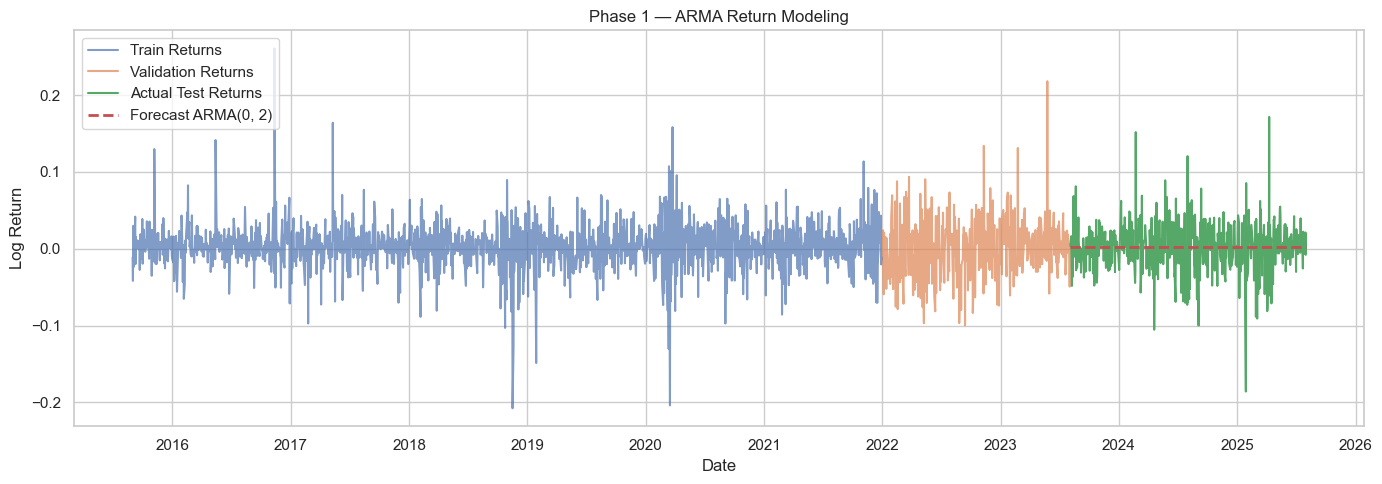

Saved: outputs_phase1\figures\14_arma_residuals.png


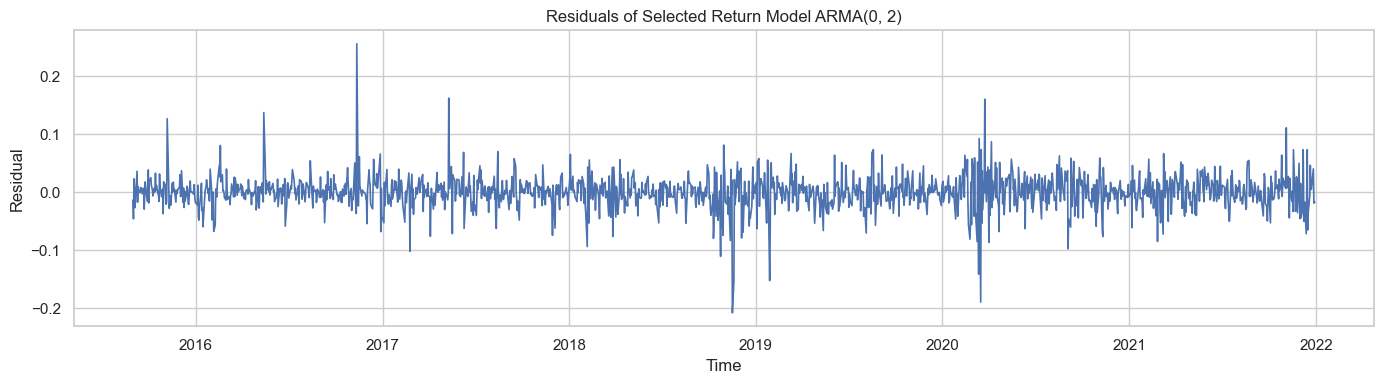

In [25]:
# =========================================================
# 9. RETURN MODELING BASELINE: ARMA — VALIDATION + TEST
# =========================================================

return_candidates = [
    (0, 0),
    (1, 0),
    (0, 1),
    (1, 1),
    (2, 0),
    (0, 2),
    (2, 1),
    (1, 2)
]

val_test_len = len(val) + len(test)

ret_sel_df, best_ret_order, ret_forecast_all, ret_resid, ret_diag, ret_fit = arma_select_and_forecast(
    train["log_return"], val_test_len, return_candidates
)

ret_val_forecast = ret_forecast_all.iloc[:len(val)] if hasattr(ret_forecast_all, "iloc") else ret_forecast_all[:len(val)]
ret_test_forecast = ret_forecast_all.iloc[len(val):] if hasattr(ret_forecast_all, "iloc") else ret_forecast_all[len(val):]

return_val_eval = pd.DataFrame([
    evaluate_forecast(f"ARMA{best_ret_order}", val["log_return"], ret_val_forecast)
]).rename(columns={
    "MAE": "Validation_MAE",
    "RMSE": "Validation_RMSE",
    "MAPE": "Validation_MAPE"
})

return_eval = pd.DataFrame([
    evaluate_forecast(f"ARMA{best_ret_order}", test["log_return"], ret_test_forecast)
])

return_eval = return_eval.merge(return_val_eval, on="Model", how="left")
return_eval["Selected_By"] = "Train_AIC"

ret_sel_df.to_csv(TABLE_DIR / "arma_return_selection.csv", index=False)
return_val_eval.to_csv(TABLE_DIR / "return_modeling_validation_evaluation.csv", index=False)
return_eval.to_csv(TABLE_DIR / "return_modeling_evaluation.csv", index=False)

print("ARMA selection on log returns:")
display(ret_sel_df)
print("Return forecasting validation evaluation:")
display(return_val_eval)
print("Return forecasting test evaluation:")
display(return_eval)

print("Residual diagnostics:")
for key, value in ret_diag.items():
    print(f"{key}: {value}")

plt.figure(figsize=(14, 5))
plt.plot(train.index, train["log_return"], label="Train Returns", alpha=0.7)
plt.plot(val.index, val["log_return"], label="Validation Returns", alpha=0.7)
plt.plot(test.index, test["log_return"], label="Actual Test Returns", linewidth=1.5)
plt.plot(test.index, ret_test_forecast, "--", label=f"Forecast ARMA{best_ret_order}", linewidth=2)
plt.title("Phase 1 — ARMA Return Modeling")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend(loc="upper left")
save_current_fig("13_arma_return_forecast.png")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(ret_resid, linewidth=1.2)
plt.title(f"Residuals of Selected Return Model ARMA{best_ret_order}")
plt.xlabel("Time")
plt.ylabel("Residual")
save_current_fig("14_arma_residuals.png")
plt.show()

In [26]:
from arch import arch_model

garch_candidates = [(1, 1), (1, 2), (2, 1), (2, 2)]
garch_results = []

train_returns_scaled = train["log_return"] * 100

for p, q in garch_candidates:
    try:
        model = arch_model(
            train_returns_scaled,
            mean="Zero",
            vol="GARCH",
            p=p,
            q=q,
            dist="normal"
        )
        fitted = model.fit(disp="off")

        garch_results.append({
            "Model": f"GARCH({p},{q})",
            "p": p,
            "q": q,
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })

    except Exception as e:
        print(f"GARCH({p},{q}) failed: {e}")

garch_results_df = pd.DataFrame(garch_results).sort_values(["AIC", "BIC"]).reset_index(drop=True)
best_garch = garch_results_df.iloc[0]

print(garch_results_df)
print("Best GARCH:", best_garch["Model"])

        Model  p  q          AIC          BIC
0  GARCH(2,2)  2  2  7744.723264  7771.599543
1  GARCH(1,1)  1  1  7752.088494  7768.214261
2  GARCH(1,2)  1  2  7754.083619  7775.584642
3  GARCH(2,1)  2  1  7754.088494  7775.589517
Best GARCH: GARCH(2,2)


In [27]:
# =========================================================
# 11. PHASE 1 SUMMARY
# =========================================================
summary_rows = [
    {"Component": "Data Cleaning", "Status": "Complete", "Output": "cleaned_nvda_phase1.csv"},
    {"Component": "Feature Engineering", "Status": "Complete", "Output": "log_price, simple_return, log_return, squared_return, realized_vol_21"},
    {"Component": "EDA", "Status": "Complete", "Output": "Figures 01–04"},
    {"Component": "Volatility Analysis", "Status": "Complete", "Output": "Figures 05–07, volatility_summary.csv"},
    {"Component": "ACF/PACF + Decomposition", "Status": "Complete", "Output": "Figures 08–11"},
    {"Component": "Stationarity Analysis", "Status": "Complete", "Output": "stationarity_tests.csv"},
    {"Component": "Classical Price Baselines", "Status": "Complete", "Output": "price_forecasting_evaluation.csv"},
    {"Component": "Return Baseline", "Status": "Complete", "Output": "return_modeling_evaluation.csv"},
    {
        "Component": "GARCH Baseline",
        "Status": "Complete" if (ARCH_AVAILABLE and best_garch is not None) else "Skipped/Optional",
        "Output": "garch_model_selection.csv" if (ARCH_AVAILABLE and best_garch is not None) else "None"
    },
]
phase1_summary = pd.DataFrame(summary_rows)
phase1_summary.to_csv(TABLE_DIR / "phase1_summary.csv", index=False)

display(phase1_summary)


,Component,Status,Output
0,Data Cleaning,Complete,cleaned_nvda_phase1.csv
1,Feature Engineering,Complete,"log_price, simple_return, log_return, squared_..."
2,EDA,Complete,Figures 01–04
3,Volatility Analysis,Complete,"Figures 05–07, volatility_summary.csv"
4,ACF/PACF + Decomposition,Complete,Figures 08–11
5,Stationarity Analysis,Complete,stationarity_tests.csv
6,Classical Price Baselines,Complete,price_forecasting_evaluation.csv
7,Return Baseline,Complete,return_modeling_evaluation.csv
8,GARCH Baseline,Complete,garch_model_selection.csv


In [28]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score
from sklearn.model_selection import TimeSeriesSplit

DATA_PATH='HistoricalData_1754061510662.csv'; TEST_SIZE=0.2; VALIDATION_SIZE=0.2; RANDOM_SEED=42; FORECAST_HORIZONS=[1,5,21]
OUTPUT_DIR=Path('outputs_phase2'); FIG_DIR=OUTPUT_DIR/'figures'; TABLE_DIR=OUTPUT_DIR/'tables'
for f in [FIG_DIR,TABLE_DIR]: f.mkdir(parents=True,exist_ok=True)

def mape(y,p):
    y=np.asarray(y,float); p=np.asarray(p,float); mask=y!=0
    return np.mean(np.abs((y[mask]-p[mask])/y[mask]))*100

def rmse(y,p): return np.sqrt(mean_squared_error(y,p))

def load_clean(path):
    df=pd.read_csv(path); df.columns=df.columns.str.strip();
    if 'Close/Last' in df: df=df.rename(columns={'Close/Last':'Close'})
    for c in ['Close','Open','High','Low','Volume']:
        if c in df:
            df[c]=pd.to_numeric(df[c].astype(str).str.replace('$','',regex=False).str.replace(',','',regex=False),errors='coerce')
    df['Date']=pd.to_datetime(df['Date'],errors='coerce')
    df=df.dropna(subset=['Date','Close']).sort_values('Date').set_index('Date')
    return df[[c for c in ['Close','Open','High','Low','Volume'] if c in df]].copy()

def features(df):
    o=df.copy(); o['log_return']=np.log(o['Close']/o['Close'].shift(1)); o['log_price']=np.log(o['Close'])
    if {'High','Low'}.issubset(o.columns): o['hl_range']=(o['High']-o['Low'])/o['Close']
    if 'Open' in o: o['oc_gap']=(o['Close']-o['Open'])/o['Open']
    if 'Volume' in o: o['volume_change']=o['Volume'].pct_change(); o['log_volume']=np.log(o['Volume'].replace(0,np.nan))
    for lag in [1,2,3,5,10,21]:
        o[f'return_lag_{lag}']=o['log_return'].shift(lag)
        if 'volume_change' in o: o[f'volume_change_lag_{lag}']=o['volume_change'].shift(lag)
    for w in [5,10,21,63]:
        o[f'return_mean_{w}']=o['log_return'].rolling(w).mean(); o[f'return_std_{w}']=o['log_return'].rolling(w).std()
        o[f'price_ma_ratio_{w}']=o['Close']/o['Close'].rolling(w).mean()-1
        o[f'price_std_ratio_{w}']=o['Close'].rolling(w).std()/o['Close'].rolling(w).mean()
    o['realized_vol_21']=o['log_return'].rolling(21).std()*np.sqrt(252); o['realized_vol_63']=o['log_return'].rolling(63).std()*np.sqrt(252)
    return o.replace([np.inf,-np.inf],np.nan)

def supervised(fd, h, use_vol=True):
    d = fd.copy()

    # Future target.
    d[f'target_ret_{h}d'] = np.log(d['Close'].shift(-h) / d['Close'])
    d[f'target_price_{h}d'] = d['Close'].shift(-h)

    # Target date is required to prevent boundary leakage.
    d[f'target_date_{h}d'] = d.index.to_series().shift(-h)

    exclude = {
        'Open', 'High', 'Low', 'Close', 'log_price',
        f'target_ret_{h}d',
        f'target_price_{h}d',
        f'target_date_{h}d'
    }

    cols = [c for c in d.columns if c not in exclude]

    if not use_vol:
        cols = [c for c in cols if not any(k in c for k in ['std', 'vol', 'range'])]

    d = d.dropna(
        subset=cols + [f'target_ret_{h}d', f'target_price_{h}d', f'target_date_{h}d']
    ).copy()

    # Chronological test boundary.
    test_start_pos = int(len(d) * (1 - TEST_SIZE))
    test_start_date = d.index[test_start_pos]

    # Pre-test block: both feature date and target date must be before test.
    pre_test = d[
        (d.index < test_start_date) &
        (d[f'target_date_{h}d'] < test_start_date)
    ].copy()

    # Chronological validation boundary inside pre-test block.
    val_start_pos = int(len(pre_test) * (1 - VALIDATION_SIZE))
    val_start_date = pre_test.index[val_start_pos]

    # Train: both feature date and target date must be before validation.
    train = pre_test[
        (pre_test.index < val_start_date) &
        (pre_test[f'target_date_{h}d'] < val_start_date)
    ].copy()

    # Validation: validation feature dates, target still before test.
    val = pre_test[
        pre_test.index >= val_start_date
    ].copy()

    # Test: feature dates in test period. Test is not used for model selection.
    test = d[
        d.index >= test_start_date
    ].copy()

    return train, val, test, cols

def models():
    return {
        'Linear Regression': Pipeline([('scaler',StandardScaler()),('model',LinearRegression())]),
        'Ridge': Pipeline([('scaler',StandardScaler()),('model',Ridge(alpha=10.0))]),
        'Random Forest': RandomForestRegressor(n_estimators=80,max_depth=5,min_samples_leaf=5,random_state=RANDOM_SEED,n_jobs=1),
        'Extra Trees': ExtraTreesRegressor(n_estimators=80,max_depth=5,min_samples_leaf=5,random_state=RANDOM_SEED,n_jobs=1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=80,learning_rate=0.05,max_depth=2,random_state=RANDOM_SEED)
    }

def eval_row(test,true_price,pred_ret,name,h):
    pred_price=test['Close'].values*np.exp(pred_ret)
    return {'Horizon':f'{h} trading day(s)','Model':name,'MAE':mean_absolute_error(true_price,pred_price),'RMSE':rmse(true_price,pred_price),'MAPE':mape(true_price,pred_price),'Directional Accuracy':accuracy_score(test[f'target_ret_{h}d'].values>0,pred_ret>0)}, pred_price

def run_horizon(fd, h, use_vol=True):
    train, val, test, cols = supervised(fd, h, use_vol)

    Xtr = train[cols]
    ytr = train[f'target_ret_{h}d']

    Xval = val[cols]
    yval_price = val[f'target_price_{h}d'].values

    Xte = test[cols]
    yte_price = test[f'target_price_{h}d'].values

    val_rows = []
    test_rows = []
    preds = {}

    # Baseline 1: Naive no-change.
    val_r, _ = eval_row(val, yval_price, np.zeros(len(val)), 'Naive No-Change', h)
    test_r, test_p = eval_row(test, yte_price, np.zeros(len(test)), 'Naive No-Change', h)
    val_rows.append(val_r)
    test_rows.append(test_r)
    preds['Naive No-Change'] = test_p

    # Baseline 2: Historical mean return from train only.
    mean_ret_val = np.repeat(ytr.mean(), len(val))
    mean_ret_test = np.repeat(ytr.mean(), len(test))

    val_r, _ = eval_row(val, yval_price, mean_ret_val, 'Historical Mean Return', h)
    test_r, test_p = eval_row(test, yte_price, mean_ret_test, 'Historical Mean Return', h)
    val_rows.append(val_r)
    test_rows.append(test_r)
    preds['Historical Mean Return'] = test_p

    fitted = {}

    for name, m in models().items():
        m.fit(Xtr, ytr)
        fitted[name] = m

        val_pred_ret = m.predict(Xval)
        test_pred_ret = m.predict(Xte)

        val_r, _ = eval_row(val, yval_price, val_pred_ret, name, h)
        test_r, test_p = eval_row(test, yte_price, test_pred_ret, name, h)

        val_rows.append(val_r)
        test_rows.append(test_r)
        preds[name] = test_p

    val_ev = pd.DataFrame(val_rows).sort_values('RMSE').reset_index(drop=True)
    test_ev = pd.DataFrame(test_rows)

    # Validation metrics decide model selection.
    val_for_merge = val_ev.rename(columns={
        'MAE': 'Validation_MAE',
        'RMSE': 'Validation_RMSE',
        'MAPE': 'Validation_MAPE',
        'Directional Accuracy': 'Validation_Directional Accuracy'
    })

    ev = (
        test_ev
        .merge(
            val_for_merge[
                ['Model', 'Validation_MAE', 'Validation_RMSE', 'Validation_MAPE', 'Validation_Directional Accuracy']
            ],
            on='Model',
            how='left'
        )
        .sort_values('Validation_RMSE')
        .reset_index(drop=True)
    )

    ev['Selected_By'] = 'Validation_RMSE'
    ev['Selected_Model'] = ev['Model'].eq(ev.iloc[0]['Model'])

    return {
        'h': h,
        'train': train,
        'val': val,
        'test': test,
        'cols': cols,
        'validation_evaluation': val_ev,
        'evaluation': ev,
        'preds': preds,
        'models': fitted
    }

def importance(res):
    best=res['evaluation'].iloc[0]['Model']
    if best not in res['models']: return pd.DataFrame()
    m=res['models'][best]
    if hasattr(m,'feature_importances_'): imp=m.feature_importances_
    elif hasattr(m,'named_steps') and hasattr(m.named_steps['model'],'coef_'): imp=np.abs(m.named_steps['model'].coef_)
    else: return pd.DataFrame()
    return pd.DataFrame({'Horizon':f"{res['h']} trading day(s)",'Model':best,'Feature':res['cols'],'Importance':imp}).sort_values('Importance',ascending=False).head(20)

def plot(res):
    # Best model is selected by validation RMSE, not test RMSE.
    best = res['evaluation'].iloc[0]['Model']
    h = res['h']
    te = res['test']
    tr = res['train']
    va = res['val']

    plt.figure(figsize=(14, 6))
    plt.plot(tr.index, tr['Close'], label='Train Close', linewidth=1.2)
    plt.plot(va.index, va['Close'], label='Validation Close', linewidth=1.2, alpha=0.8)
    plt.plot(te.index, te[f'target_price_{h}d'], label='Actual Future Price', linewidth=2)
    plt.plot(te.index, res['preds'][best], '--', label=f'Validation-Selected Forecast: {best}', linewidth=2)

    plt.title(f'Phase 2 - Validation-Selected ML Forecast ({h} trading day horizon)')
    plt.xlabel('Date')
    plt.ylabel('NVDA Close Price')
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'phase2_best_forecast_{h}d.png', dpi=300, bbox_inches='tight')
    plt.close()

raw=load_clean(DATA_PATH); fd=features(raw)
all_ev=[]; all_imp=[]; results={}
for h in FORECAST_HORIZONS:
    res = run_horizon(fd, h, True)
    results[h] = res

    res['validation_evaluation'].to_csv(
        TABLE_DIR / f'phase2_validation_evaluation_{h}d.csv',
        index=False
    )
    res['evaluation'].to_csv(
        TABLE_DIR / f'phase2_evaluation_{h}d.csv',
        index=False
    )

    all_ev.append(res['evaluation'])
    plot(res)

    imp = importance(res)
    if not imp.empty:
        imp.to_csv(TABLE_DIR / f'phase2_feature_importance_{h}d.csv', index=False)
        all_imp.append(imp)

summary = pd.concat(all_ev, ignore_index=True)
summary.to_csv(TABLE_DIR / 'phase2_all_model_comparison.csv', index=False)

# Ablation for 5-day horizon.
# Selection is based on validation RMSE, while reported RMSE is test RMSE.
abl_full = results[5]['evaluation'].assign(Feature_Set='Full Feature Set')
abl_no_vol = run_horizon(fd, 5, False)['evaluation'].assign(Feature_Set='Without Volatility Features')

abl = pd.concat([abl_full, abl_no_vol], ignore_index=True)
abl.to_csv(TABLE_DIR / 'phase2_ablation_5d.csv', index=False)

print(summary)

print('\nSelected model per horizon, based on validation RMSE:')
print(
    summary
    .sort_values('Validation_RMSE')
    .groupby('Horizon')
    .head(1)[
        ['Horizon', 'Model', 'Validation_RMSE', 'RMSE', 'MAPE', 'Directional Accuracy']
    ]
)

print('\nAblation selected rows, based on validation RMSE:')
print(
    abl
    .sort_values(['Feature_Set', 'Validation_RMSE'])
    .groupby('Feature_Set')
    .head(1)[
        ['Feature_Set', 'Model', 'Validation_RMSE', 'RMSE', 'MAPE', 'Directional Accuracy']
    ]
)


              Horizon                   Model        MAE       RMSE  \
0    1 trading day(s)  Historical Mean Return   2.440814   3.541843   
1    1 trading day(s)             Extra Trees   2.395567   3.468730   
2    1 trading day(s)         Naive No-Change   2.458409   3.548456   
3    1 trading day(s)           Random Forest   2.403643   3.483977   
4    1 trading day(s)       Gradient Boosting   2.407718   3.489521   
5    1 trading day(s)                   Ridge   2.400228   3.515638   
6    1 trading day(s)       Linear Regression   2.380456   3.491828   
7    5 trading day(s)  Historical Mean Return   5.638742   7.480141   
8    5 trading day(s)         Naive No-Change   5.786673   7.561157   
9    5 trading day(s)             Extra Trees   5.850597   7.740421   
10   5 trading day(s)       Gradient Boosting   5.865534   7.727181   
11   5 trading day(s)           Random Forest   5.861102   7.807306   
12   5 trading day(s)                   Ridge   5.660597   7.630012   
13   5

In [29]:
# =========================================================
# PHASE 3 — DEEP LEARNING SEQUENCE FORECASTING FOR NVDA
# =========================================================
# Purpose:
# 1) Extend Phase 2 ML forecasting with sequence-based deep learning models.
# 2) Use LSTM and GRU to forecast future log returns.
# 3) Reconstruct future prices and evaluate with the same metrics as Phase 2.
# 4) Export report-ready tables and figures for final comparison.

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# -----------------------------
# Global configuration
# -----------------------------
DATA_PATH = 'HistoricalData_1754061510662.csv'
TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20
RANDOM_SEED = 42
FORECAST_HORIZONS = [1, 5, 21]
LOOKBACK_WINDOW = 60
MAX_EPOCHS = 80
PATIENCE = 10
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
HIDDEN_SIZE = 32
NUM_LAYERS = 1

OUTPUT_DIR = Path('outputs_phase3')
FIG_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'
for folder in [FIG_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


# -----------------------------
# Metrics
# -----------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_price_forecast(horizon, model_name, true_price, pred_price, true_ret, pred_ret):
    return {
        'Horizon': f'{horizon} trading day(s)',
        'Model': model_name,
        'MAE': mean_absolute_error(true_price, pred_price),
        'RMSE': rmse(true_price, pred_price),
        'MAPE': mape(true_price, pred_price),
        'Directional Accuracy': accuracy_score(true_ret > 0, pred_ret > 0)
    }


# -----------------------------
# Data preparation
# -----------------------------
def load_clean(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    if 'Close/Last' in df.columns:
        df = df.rename(columns={'Close/Last': 'Close'})

    for col in ['Close', 'Open', 'High', 'Low', 'Volume']:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col].astype(str)
                .str.replace('$', '', regex=False)
                .str.replace(',', '', regex=False),
                errors='coerce'
            )

    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date', 'Close']).sort_values('Date').set_index('Date')
    keep_cols = [c for c in ['Close', 'Open', 'High', 'Low', 'Volume'] if c in df.columns]
    return df[keep_cols].copy()


def create_features(df):
    out = df.copy()
    out['log_price'] = np.log(out['Close'])
    out['log_return'] = np.log(out['Close'] / out['Close'].shift(1))

    if {'High', 'Low'}.issubset(out.columns):
        out['hl_range'] = (out['High'] - out['Low']) / out['Close']

    if 'Open' in out.columns:
        out['oc_gap'] = (out['Close'] - out['Open']) / out['Open']

    if 'Volume' in out.columns:
        out['volume_change'] = out['Volume'].pct_change()
        out['log_volume'] = np.log(out['Volume'].replace(0, np.nan))

    for lag in [1, 2, 3, 5, 10, 21]:
        out[f'return_lag_{lag}'] = out['log_return'].shift(lag)
        out[f'price_momentum_{lag}'] = out['Close'] / out['Close'].shift(lag) - 1
        if 'volume_change' in out.columns:
            out[f'volume_change_lag_{lag}'] = out['volume_change'].shift(lag)

    for window in [5, 10, 21, 63]:
        out[f'return_mean_{window}'] = out['log_return'].rolling(window).mean()
        out[f'return_std_{window}'] = out['log_return'].rolling(window).std()
        out[f'price_ma_ratio_{window}'] = out['Close'] / out['Close'].rolling(window).mean() - 1
        out[f'price_std_ratio_{window}'] = out['Close'].rolling(window).std() / out['Close'].rolling(window).mean()

    out['realized_vol_21'] = out['log_return'].rolling(21).std() * np.sqrt(252)
    out['realized_vol_63'] = out['log_return'].rolling(63).std() * np.sqrt(252)

    return out.replace([np.inf, -np.inf], np.nan)


def make_sequence_dataset(feature_df, horizon, lookback=60):
    df = feature_df.copy()

    # Future target.
    df[f'target_ret_{horizon}d'] = np.log(df['Close'].shift(-horizon) / df['Close'])
    df[f'target_price_{horizon}d'] = df['Close'].shift(-horizon)
    df[f'target_date_{horizon}d'] = df.index.to_series().shift(-horizon)

    exclude = {
        'Open', 'High', 'Low', 'Close',
        f'target_ret_{horizon}d',
        f'target_price_{horizon}d',
        f'target_date_{horizon}d'
    }

    feature_cols = [c for c in df.columns if c not in exclude]

    df = df.dropna(
        subset=feature_cols + [
            f'target_ret_{horizon}d',
            f'target_price_{horizon}d',
            f'target_date_{horizon}d'
        ]
    ).copy()

    X, y_ret, y_price, current_close, dates, target_dates = [], [], [], [], [], []

    values = df[feature_cols].values.astype(np.float32)
    target_ret = df[f'target_ret_{horizon}d'].values.astype(np.float32)
    target_price = df[f'target_price_{horizon}d'].values.astype(np.float32)
    close_now = df['Close'].values.astype(np.float32)
    idx = pd.to_datetime(df.index)
    target_idx = pd.to_datetime(df[f'target_date_{horizon}d'])

    for i in range(lookback - 1, len(df)):
        X.append(values[i - lookback + 1:i + 1])
        y_ret.append(target_ret[i])
        y_price.append(target_price[i])
        current_close.append(close_now[i])
        dates.append(idx[i])
        target_dates.append(target_idx.iloc[i])

    X = np.asarray(X, dtype=np.float32)
    y_ret = np.asarray(y_ret, dtype=np.float32)
    y_price = np.asarray(y_price, dtype=np.float32)
    current_close = np.asarray(current_close, dtype=np.float32)
    dates = pd.to_datetime(pd.Index(dates))
    target_dates = pd.to_datetime(pd.Index(target_dates))

    # Test boundary based on feature dates.
    test_start_pos = int(len(X) * (1 - TEST_SIZE))
    test_start_date = dates[test_start_pos]

    # Pre-test samples must have both input date and target date before test.
    pre_test_mask = (dates < test_start_date) & (target_dates < test_start_date)
    pre_test_dates = dates[pre_test_mask]

    # Validation boundary inside pre-test block.
    val_start_pos = int(len(pre_test_dates) * (1 - VALIDATION_SIZE))
    val_start_date = pre_test_dates[val_start_pos]

    # Train samples must not have targets crossing into validation.
    train_mask = (dates < val_start_date) & (target_dates < val_start_date)

    # Validation samples must not have targets crossing into test.
    val_mask = (dates >= val_start_date) & (dates < test_start_date) & (target_dates < test_start_date)

    # Test samples are untouched and used only for final reporting.
    test_mask = dates >= test_start_date

    X_train, X_val, X_test = X[train_mask], X[val_mask], X[test_mask]
    y_train, y_val, y_test = y_ret[train_mask], y_ret[val_mask], y_ret[test_mask]

    price_val = y_price[val_mask]
    price_test = y_price[test_mask]

    close_val = current_close[val_mask]
    close_test = current_close[test_mask]

    date_train = dates[train_mask]
    date_val = dates[val_mask]
    date_test = dates[test_mask]

    # Scale features using train only to avoid leakage.
    x_scaler = StandardScaler()

    n_train, seq_len, n_features = X_train.shape

    X_train_2d = X_train.reshape(-1, n_features)
    X_val_2d = X_val.reshape(-1, n_features)
    X_test_2d = X_test.reshape(-1, n_features)

    X_train_scaled = x_scaler.fit_transform(X_train_2d).reshape(n_train, seq_len, n_features)
    X_val_scaled = x_scaler.transform(X_val_2d).reshape(X_val.shape[0], seq_len, n_features)
    X_test_scaled = x_scaler.transform(X_test_2d).reshape(X_test.shape[0], seq_len, n_features)

    # Scale target returns using train only.
    y_scaler = StandardScaler()
    y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel().astype(np.float32)
    y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).ravel().astype(np.float32)

    return {
        'X_train': X_train_scaled.astype(np.float32),
        'X_val': X_val_scaled.astype(np.float32),
        'X_test': X_test_scaled.astype(np.float32),

        'y_train': y_train.astype(np.float32),
        'y_val': y_val.astype(np.float32),
        'y_test': y_test.astype(np.float32),

        'y_train_scaled': y_train_scaled,
        'y_val_scaled': y_val_scaled,

        'price_val': price_val.astype(np.float32),
        'price_test': price_test.astype(np.float32),

        'close_val': close_val.astype(np.float32),
        'close_test': close_test.astype(np.float32),

        'date_train': date_train,
        'date_val': date_val,
        'date_test': date_test,

        'feature_cols': feature_cols,
        'x_scaler': x_scaler,
        'y_scaler': y_scaler
    }


# -----------------------------
# Deep learning models
# -----------------------------
class SequenceRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, model_type='LSTM'):
        super().__init__()
        self.model_type = model_type.upper()
        if self.model_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        elif self.model_type == 'GRU':
            self.rnn = nn.GRU(input_size, hidden_size, num_layers=num_layers, batch_first=True)
        else:
            raise ValueError('model_type must be LSTM or GRU')
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        output, _ = self.rnn(x)
        last_hidden = output[:, -1, :]
        return self.head(last_hidden).squeeze(-1)


def train_sequence_model(
    model,
    X_train,
    y_train_scaled,
    X_val,
    y_val_scaled,
    max_epochs=80,
    patience=10
):
    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train_scaled))

    val_x = torch.tensor(X_val).to(DEVICE)
    val_y = torch.tensor(y_val_scaled).to(DEVICE)

    loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.MSELoss()

    best_state = None
    best_val = np.inf
    wait = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_pred = model(val_x)
            val_loss = loss_fn(val_pred, val_y).item()

        avg_train_loss = float(np.mean(train_losses))

        history.append({
            'epoch': epoch,
            'train_loss': avg_train_loss,
            'val_loss': val_loss
        })

        if val_loss < best_val:
            best_val = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


def predict_returns(model, X_test, y_scaler):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(X_test).to(DEVICE)
        pred_scaled = model(x).detach().cpu().numpy().reshape(-1, 1)
    pred_ret = y_scaler.inverse_transform(pred_scaled).ravel()
    return pred_ret


# -----------------------------
# Plots and main experiment
# -----------------------------
def plot_loss(history, model_name, horizon):
    plt.figure(figsize=(10, 5))
    plt.plot(history['epoch'], history['train_loss'], label='Train Loss')
    plt.plot(history['epoch'], history['val_loss'], label='Validation Loss')
    plt.title(f'Phase 3 - {model_name} Training Curve ({horizon}d Horizon)')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss on Scaled Return')
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'phase3_loss_{model_name.lower()}_{horizon}d.png', dpi=300, bbox_inches='tight')
    plt.close()


def plot_best_forecast(dataset, predictions, best_model, horizon):
    dates = dataset['date_test']
    actual = dataset['price_test']
    pred = predictions[best_model]

    plt.figure(figsize=(14, 6))
    plt.plot(dates, actual, label='Actual Future Price', linewidth=2)
    plt.plot(dates, pred, '--', label=f'Best DL Forecast: {best_model}', linewidth=2)
    plt.title(f'Phase 3 - Best Deep Learning Forecast ({horizon} Trading Day Horizon)')
    plt.xlabel('Date')
    plt.ylabel('NVDA Close Price')
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'phase3_best_dl_forecast_{horizon}d.png', dpi=300, bbox_inches='tight')
    plt.close()


def run_horizon(feature_df, horizon):
    data = make_sequence_dataset(feature_df, horizon, LOOKBACK_WINDOW)

    val_rows = []
    test_rows = []
    predictions = {}

    # Baseline 1: no-change future return.
    naive_val_ret = np.zeros(len(data['y_val']), dtype=np.float32)
    naive_test_ret = np.zeros(len(data['y_test']), dtype=np.float32)

    naive_val_price = data['close_val'] * np.exp(naive_val_ret)
    naive_test_price = data['close_test'] * np.exp(naive_test_ret)

    val_rows.append(
        evaluate_price_forecast(
            horizon,
            'Naive No-Change',
            data['price_val'],
            naive_val_price,
            data['y_val'],
            naive_val_ret
        )
    )

    test_rows.append(
        evaluate_price_forecast(
            horizon,
            'Naive No-Change',
            data['price_test'],
            naive_test_price,
            data['y_test'],
            naive_test_ret
        )
    )

    predictions['Naive No-Change'] = naive_test_price

    # Baseline 2: historical mean return from train only.
    mean_val_ret = np.repeat(data['y_train'].mean(), len(data['y_val'])).astype(np.float32)
    mean_test_ret = np.repeat(data['y_train'].mean(), len(data['y_test'])).astype(np.float32)

    mean_val_price = data['close_val'] * np.exp(mean_val_ret)
    mean_test_price = data['close_test'] * np.exp(mean_test_ret)

    val_rows.append(
        evaluate_price_forecast(
            horizon,
            'Historical Mean Return',
            data['price_val'],
            mean_val_price,
            data['y_val'],
            mean_val_ret
        )
    )

    test_rows.append(
        evaluate_price_forecast(
            horizon,
            'Historical Mean Return',
            data['price_test'],
            mean_test_price,
            data['y_test'],
            mean_test_ret
        )
    )

    predictions['Historical Mean Return'] = mean_test_price

    trained_models = {}
    histories = {}

    for model_name in ['LSTM', 'GRU']:
        set_seed(RANDOM_SEED)

        model = SequenceRegressor(
            input_size=data['X_train'].shape[-1],
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            model_type=model_name
        )

        model, history = train_sequence_model(
            model,
            data['X_train'],
            data['y_train_scaled'],
            data['X_val'],
            data['y_val_scaled'],
            MAX_EPOCHS,
            PATIENCE
        )

        # Validation prediction for model selection.
        val_pred_ret = predict_returns(model, data['X_val'], data['y_scaler'])
        val_pred_price = data['close_val'] * np.exp(val_pred_ret)

        val_rows.append(
            evaluate_price_forecast(
                horizon,
                model_name,
                data['price_val'],
                val_pred_price,
                data['y_val'],
                val_pred_ret
            )
        )

        # Test prediction for final reporting only.
        test_pred_ret = predict_returns(model, data['X_test'], data['y_scaler'])
        test_pred_price = data['close_test'] * np.exp(test_pred_ret)

        test_rows.append(
            evaluate_price_forecast(
                horizon,
                model_name,
                data['price_test'],
                test_pred_price,
                data['y_test'],
                test_pred_ret
            )
        )

        predictions[model_name] = test_pred_price
        trained_models[model_name] = model
        histories[model_name] = history

        history.to_csv(
            TABLE_DIR / f'phase3_training_history_{model_name.lower()}_{horizon}d.csv',
            index=False
        )

        plot_loss(history, model_name, horizon)

    validation_evaluation = pd.DataFrame(val_rows).sort_values('RMSE').reset_index(drop=True)
    test_evaluation = pd.DataFrame(test_rows)

    val_for_merge = validation_evaluation.rename(columns={
        'MAE': 'Validation_MAE',
        'RMSE': 'Validation_RMSE',
        'MAPE': 'Validation_MAPE',
        'Directional Accuracy': 'Validation_Directional Accuracy'
    })

    evaluation = (
        test_evaluation
        .merge(
            val_for_merge[
                ['Model', 'Validation_MAE', 'Validation_RMSE', 'Validation_MAPE', 'Validation_Directional Accuracy']
            ],
            on='Model',
            how='left'
        )
        .sort_values('Validation_RMSE')
        .reset_index(drop=True)
    )

    evaluation['Selected_By'] = 'Validation_RMSE'
    evaluation['Selected_Model'] = evaluation['Model'].eq(evaluation.iloc[0]['Model'])

    validation_evaluation.to_csv(
        TABLE_DIR / f'phase3_validation_evaluation_{horizon}d.csv',
        index=False
    )

    evaluation.to_csv(
        TABLE_DIR / f'phase3_evaluation_{horizon}d.csv',
        index=False
    )

    best_model = evaluation.iloc[0]['Model']
    plot_best_forecast(data, predictions, best_model, horizon)

    return {
        'horizon': horizon,
        'data': data,
        'validation_evaluation': validation_evaluation,
        'evaluation': evaluation,
        'predictions': predictions,
        'models': trained_models,
        'histories': histories,
        'best_model': best_model
    }


# -----------------------------
# Execute Phase 3
# -----------------------------
raw = load_clean(DATA_PATH)
feature_df = create_features(raw)

print('=' * 80)
print('PHASE 3 — DEEP LEARNING SEQUENCE FORECASTING')
print('=' * 80)
print(f'Dataset range: {raw.index.min().date()} to {raw.index.max().date()}')
print(f'Rows: {len(raw)}')
print(f'Lookback window: {LOOKBACK_WINDOW} trading days')
print(f'Forecast horizons: {FORECAST_HORIZONS}')

all_results = []
phase3_results = {}

for horizon in FORECAST_HORIZONS:
    print('\n' + '=' * 80)
    print(f'Running horizon: {horizon} trading day(s)')
    print('=' * 80)
    result = run_horizon(feature_df, horizon)
    phase3_results[horizon] = result
    all_results.append(result['evaluation'])
    print(result['evaluation'])

phase3_summary = pd.concat(all_results, ignore_index=True)
phase3_summary.to_csv(TABLE_DIR / 'phase3_all_model_comparison.csv', index=False)

best_per_horizon = (
    phase3_summary.sort_values('Validation_RMSE')
    .groupby('Horizon')
    .head(1)[
        ['Horizon', 'Model', 'Validation_RMSE', 'RMSE', 'MAPE', 'Directional Accuracy']
    ]
    .reset_index(drop=True)
)
best_per_horizon.to_csv(TABLE_DIR / 'phase3_best_per_horizon.csv', index=False)

print('\n' + '=' * 80)
print('PHASE 3 SUMMARY — BEST MODEL PER HORIZON')
print('=' * 80)
print(best_per_horizon)

print('\nSaved outputs to:')
print(f'- Tables : {TABLE_DIR}')
print(f'- Figures: {FIG_DIR}')


# =========================================================
# OPTIONAL: MERGE PHASE 2 AND PHASE 3 RESULTS
# =========================================================
phase2_path = Path('outputs_phase2/tables/phase2_all_model_comparison.csv')
phase3_path = TABLE_DIR / 'phase3_all_model_comparison.csv'

if phase2_path.exists() and phase3_path.exists():
    phase2 = pd.read_csv(phase2_path)
    phase3 = pd.read_csv(phase3_path)
    phase2['Method_Family'] = 'Feature-based ML'
    phase3['Method_Family'] = 'Sequence-based DL'
    combined = pd.concat([phase2, phase3], ignore_index=True)
    sort_metric = 'Validation_RMSE' if 'Validation_RMSE' in combined.columns else 'RMSE'
    combined = combined.sort_values(['Horizon', sort_metric]).reset_index(drop=True)
    combined.to_csv(TABLE_DIR / 'phase2_phase3_combined_comparison.csv', index=False)
    print('\nCombined Phase 2 + Phase 3 comparison:')
    print(combined.groupby('Horizon').head(5)[['Horizon', 'Method_Family', 'Model', 'RMSE', 'MAPE', 'Directional Accuracy']])
else:
    print('\nPhase 2 output not found. Run Phase 2 first if you want a combined ML vs DL comparison table.')


Using device: cpu
PHASE 3 — DEEP LEARNING SEQUENCE FORECASTING
Dataset range: 2015-07-31 to 2025-07-31
Rows: 2515
Lookback window: 60 trading days
Forecast horizons: [1, 5, 21]

Running horizon: 1 trading day(s)
            Horizon                   Model       MAE      RMSE      MAPE  \
0  1 trading day(s)                     GRU  2.481243  3.574856  2.354475   
1  1 trading day(s)                    LSTM  2.471713  3.575761  2.343758   
2  1 trading day(s)  Historical Mean Return  2.477831  3.579396  2.349281   
3  1 trading day(s)         Naive No-Change  2.495812  3.585799  2.365433   

   Directional Accuracy  Validation_MAE  Validation_RMSE  Validation_MAPE  \
0              0.521921        0.629743         0.887104         2.811447   
1              0.555324        0.631428         0.887164         2.820688   
2              0.559499        0.630222         0.887661         2.811529   
3              0.440501        0.630060         0.890981         2.808097   

   Validation_Di

Phase 4 output directory: C:\Users\htc\Desktop\notebook\Kì 4\Time series\Single-Stock-Case-Study-NVIDIA-NVDA-\outputs_phase4
Loaded Phase 1 price evaluation: outputs_phase1\tables\price_forecasting_evaluation.csv
Loaded Phase 1 return evaluation: outputs_phase1\tables\return_modeling_evaluation.csv
Missing Phase 1 GARCH selection: outputs_phase1\tables\garch_model_selection.csv
Loaded Phase 2 ML comparison: outputs_phase2\tables\phase2_all_model_comparison.csv
Loaded Phase 2 ablation: outputs_phase2\tables\phase2_ablation_5d.csv
Loaded Phase 3 DL comparison: outputs_phase3\tables\phase3_all_model_comparison.csv
Saved standardized comparison table.
Best model by horizon:


,Horizon,Phase,Model Family,Model,MAE,RMSE,MAPE,Directional Accuracy
0,1 trading day(s),Phase 2,Feature-based ML,Extra Trees,2.395567,3.468730,2.302057,0.564155
1,5 trading day(s),Phase 2,Feature-based ML,Historical Mean Return,5.638742,7.480141,5.496580,0.612245
2,21 trading day(s),Phase 2,Feature-based ML,Historical Mean Return,11.289293,14.141941,10.781871,0.650924



Model family summary:


,Horizon Days,Model Family,Best_RMSE,Median_RMSE,Best_MAPE,Median_Directional_Accuracy
0,1.0,Feature-based ML,3.468730,3.491828,2.292811,0.560081
1,1.0,Sequence-based DL,3.574856,3.577578,2.343758,0.538622
2,5.0,Feature-based ML,7.480141,7.652247,5.496580,0.571429
3,5.0,Sequence-based DL,7.564158,7.605072,5.531002,0.579498
4,21.0,Feature-based ML,14.141941,15.412922,10.781871,0.648871
5,21.0,Sequence-based DL,14.330743,14.687663,10.996838,0.642105


,Horizon,Phase,Model Family,Model,RMSE,MAPE,Directional Accuracy,Selection Rank,Test RMSE Rank,Test MAPE Rank,Directional Rank,Average Reporting Rank
0,1 trading day(s),Phase 2,Feature-based ML,Extra Trees,3.468730,2.302057,0.564155,1.0,1.0,2.0,3.0,2.000000
1,1 trading day(s),Phase 2,Feature-based ML,Random Forest,3.483977,2.309957,0.560081,2.0,2.0,3.0,4.0,3.000000
2,1 trading day(s),Phase 2,Feature-based ML,Gradient Boosting,3.489521,2.314212,0.556008,3.0,3.0,5.0,6.0,4.666667
3,1 trading day(s),Phase 2,Feature-based ML,Linear Regression,3.491828,2.292811,0.578411,4.0,4.0,1.0,1.0,2.000000
4,1 trading day(s),Phase 2,Feature-based ML,Ridge,3.515638,2.311154,0.572301,5.0,5.0,4.0,2.0,3.666667
5,1 trading day(s),Phase 2,Feature-based ML,Historical Mean Return,3.541843,2.342106,0.560081,6.0,6.0,6.0,4.0,5.333333
6,1 trading day(s),Phase 2,Feature-based ML,Naive No-Change,3.548456,2.357905,0.439919,7.0,7.0,10.0,10.0,9.000000
7,1 trading day(s),Phase 3,Sequence-based DL,GRU,3.574856,2.354475,0.521921,8.0,8.0,9.0,8.0,8.333333
8,1 trading day(s),Phase 3,Sequence-based DL,LSTM,3.575761,2.343758,0.555324,9.0,9.0,7.0,7.0,7.666667
9,1 trading day(s),Phase 3,Sequence-based DL,Historical Mean Return,3.579396,2.349281,0.559499,10.0,10.0,8.0,5.0,7.666667


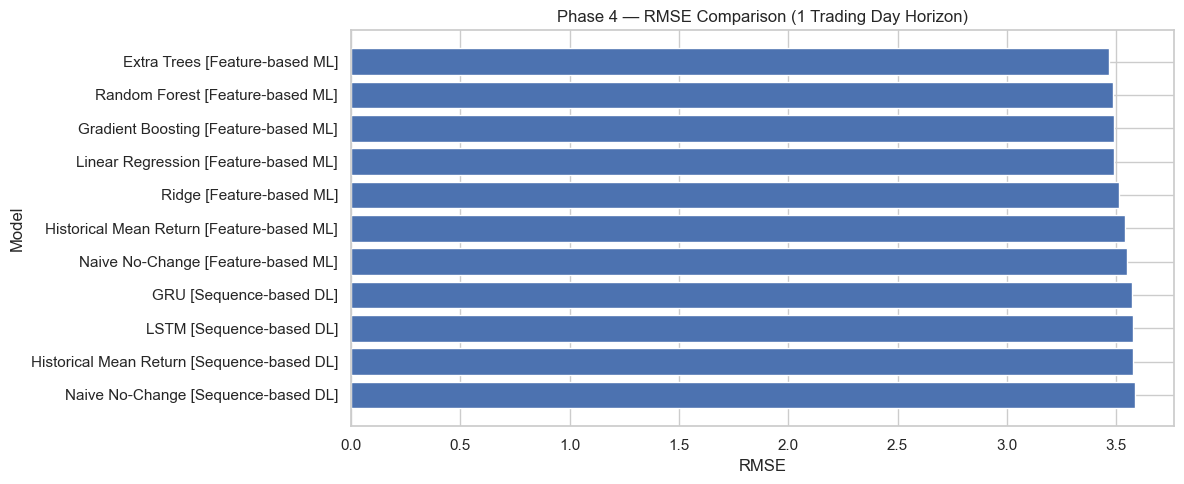

Saved figure: outputs_phase4\figures\phase4_rmse_comparison_1d.png


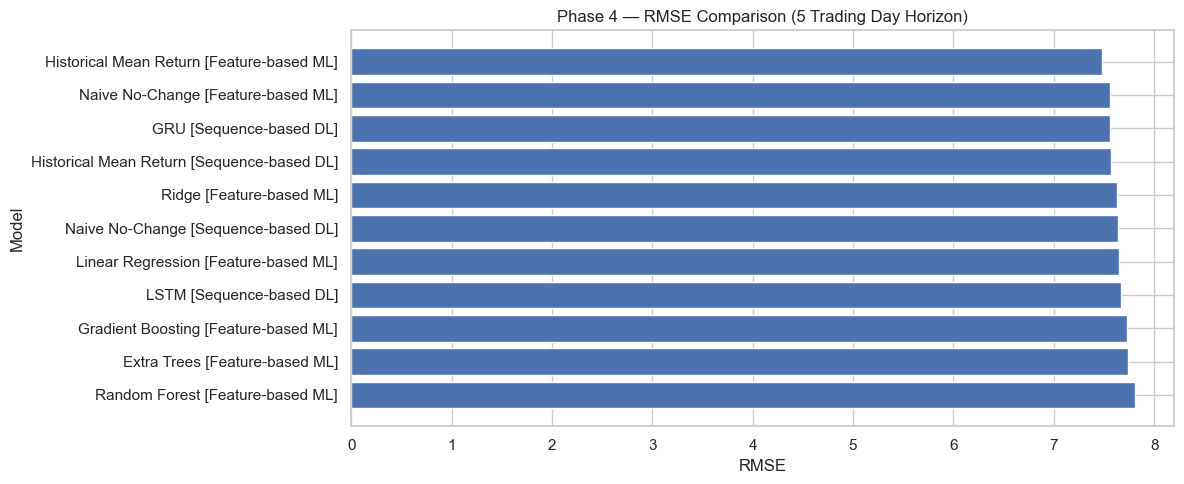

Saved figure: outputs_phase4\figures\phase4_rmse_comparison_5d.png


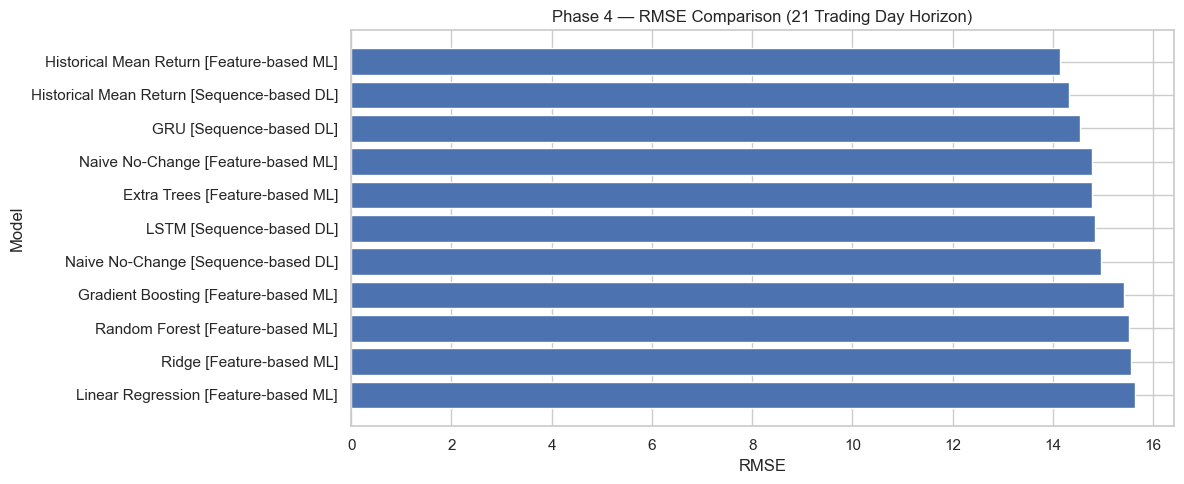

Saved figure: outputs_phase4\figures\phase4_rmse_comparison_21d.png


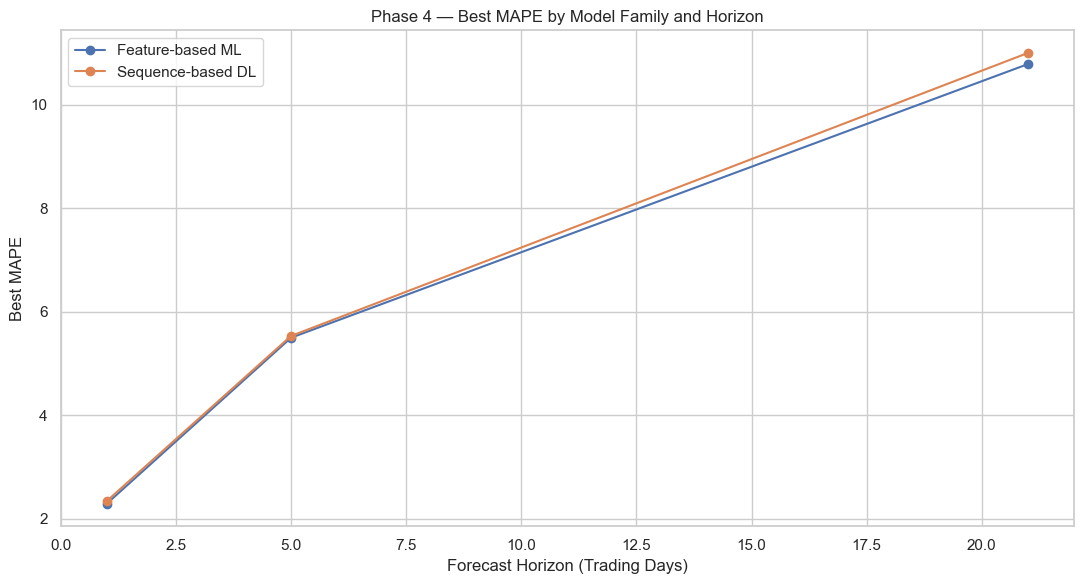

Saved figure: outputs_phase4\figures\phase4_best_mape_by_family.png


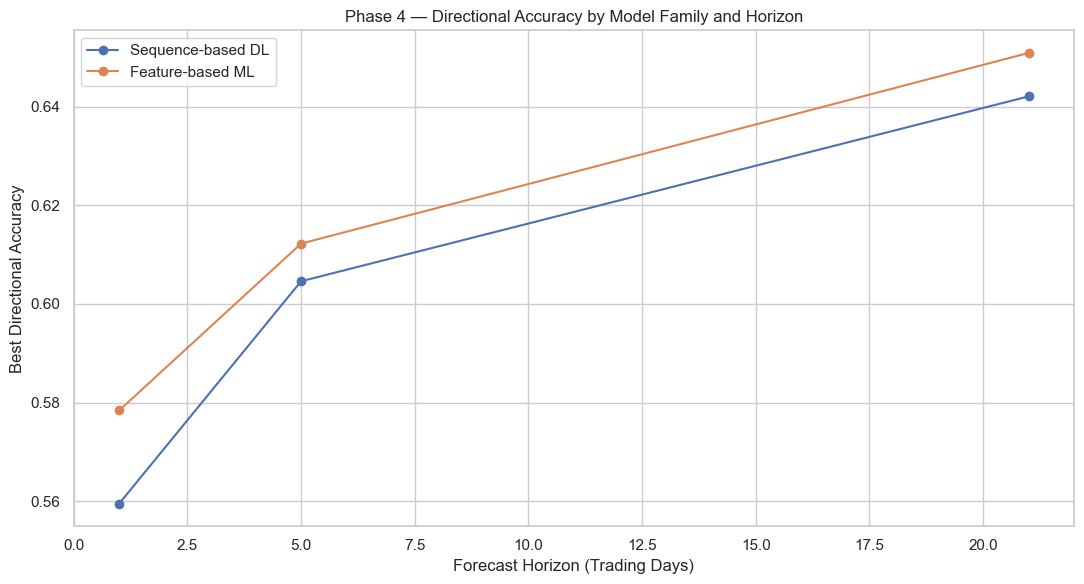

Saved figure: outputs_phase4\figures\phase4_directional_accuracy_by_family.png
Phase 2 ablation evidence:


,Horizon,Model,MAE,RMSE,MAPE,Directional Accuracy,Validation_MAE,Validation_RMSE,Validation_MAPE,Validation_Directional Accuracy,Selected_By,Selected_Model,Feature_Set
0,5 trading day(s),Historical Mean Return,5.638742,7.480141,5.496580,0.612245,1.405391,1.895978,6.445849,0.565217,Validation_RMSE,True,Full Feature Set
1,5 trading day(s),Naive No-Change,5.786673,7.561157,5.611791,0.387755,1.411566,1.911931,6.435673,0.434783,Validation_RMSE,False,Full Feature Set
2,5 trading day(s),Extra Trees,5.850597,7.740421,5.679314,0.534694,1.426659,1.918491,6.513123,0.539642,Validation_RMSE,False,Full Feature Set
3,5 trading day(s),Gradient Boosting,5.865534,7.727181,5.710639,0.561224,1.443551,1.919628,6.629019,0.521739,Validation_RMSE,False,Full Feature Set
4,5 trading day(s),Random Forest,5.861102,7.807306,5.688583,0.573469,1.449746,1.948362,6.649885,0.501279,Validation_RMSE,False,Full Feature Set
5,5 trading day(s),Ridge,5.660597,7.630012,5.564854,0.577551,1.445882,1.952358,6.620459,0.526854,Validation_RMSE,False,Full Feature Set
6,5 trading day(s),Linear Regression,5.669757,7.652247,5.577313,0.571429,1.449895,1.957404,6.631062,0.529412,Validation_RMSE,False,Full Feature Set
7,5 trading day(s),Historical Mean Return,5.638742,7.480141,5.496580,0.612245,1.405391,1.895978,6.445849,0.565217,Validation_RMSE,True,Without Volatility Features
8,5 trading day(s),Extra Trees,5.648175,7.491829,5.515546,0.583673,1.411076,1.901398,6.519849,0.542199,Validation_RMSE,False,Without Volatility Features
9,5 trading day(s),Naive No-Change,5.786673,7.561157,5.611791,0.387755,1.411566,1.911931,6.435673,0.434783,Validation_RMSE,False,Without Volatility Features


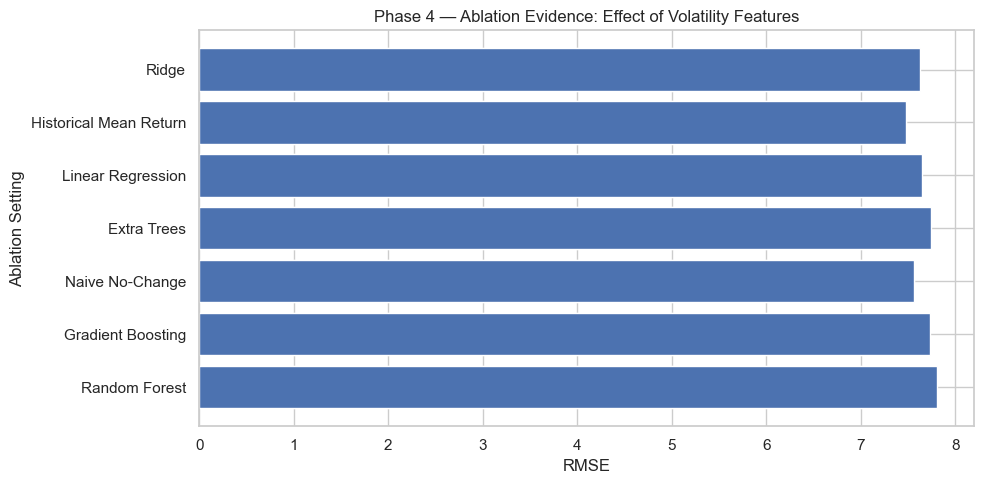

Saved figure: outputs_phase4\figures\phase4_ablation_volatility_features_rmse.png
Phase 4 Contribution Evidence Summary

Proposed project contribution:
This project evaluates NVDA forecasting through a layered pipeline that moves from classical statistical baselines to feature-based machine learning and then to sequence-based deep learning. The contribution is not merely adding models; it is a controlled comparison framework that tests whether engineered lag, volatility, momentum, and sequence information improve short- and medium-horizon forecasting evidence.

Best model by forecast horizon:
- 1 trading day(s): Extra Trees (Feature-based ML) selected by RMSE=3.4687; test RMSE=3.4687, test MAPE=2.3021, test Directional Accuracy=0.5642.
- 5 trading day(s): Historical Mean Return (Feature-based ML) selected by RMSE=7.4801; test RMSE=7.4801, test MAPE=5.4966, test Directional Accuracy=0.6122.
- 21 trading day(s): Historical Mean Return (Feature-based ML) selected by RMSE=14.1419; test RMS

,Report Section,Use Phase 4 Output
0,Introduction,Use contribution statement and best-horizon ev...
1,Methodology,Describe the layered comparison design: classi...
2,Results,Insert phase4_all_model_comparison_standardize...
3,Results,Insert RMSE/MAPE/directional accuracy plots fr...
4,Discussion,Explain why models succeed/fail by horizon and...
5,Limitations,"Mention single-stock scope, unstable market re..."
6,Conclusion,Restate which modeling layer gives the stronge...


In [32]:

# =========================================================
# PHASE 4 — FINAL COMPARISON AND CONTRIBUTION EVIDENCE
# =========================================================
# This notebook is designed to be run after:
# - Phase_1_Foundation_Pipeline_NVDA.ipynb
# - Phase_2_ML_Forecasting_NVDA.ipynb
# - Phase_3_DL_Sequence_Forecasting_NVDA.ipynb
#
# It reads their exported tables, standardizes them, ranks models,
# creates report-ready plots, and writes summary evidence for the final paper.

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 0. Configuration
# ---------------------------------------------------------
DATA_PATH = Path('HistoricalData_1754061510662.csv')

PHASE1_TABLE_DIR = Path('outputs_phase1/tables')
PHASE2_TABLE_DIR = Path('outputs_phase2/tables')
PHASE3_TABLE_DIR = Path('outputs_phase3/tables')

OUTPUT_DIR = Path('outputs_phase4')
FIG_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'
TEXT_DIR = OUTPUT_DIR / 'text'

for p in [FIG_DIR, TABLE_DIR, TEXT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 6)

print('Phase 4 output directory:', OUTPUT_DIR.resolve())


# ---------------------------------------------------------
# 1. Utility functions
# ---------------------------------------------------------
def read_csv_if_exists(path: Path, label: str) -> pd.DataFrame:
    if path.exists():
        print(f'Loaded {label}: {path}')
        return pd.read_csv(path)
    print(f'Missing {label}: {path}')
    return pd.DataFrame()


def parse_horizon_days(value):
    """Convert strings such as '5 trading day(s)' into integer 5.
    Non-horizon values become NaN.
    """
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return int(value)
    m = re.search(r'(\d+)', str(value))
    return int(m.group(1)) if m else np.nan


def standardize_metric_columns(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()
    # Normalize common column names if needed.
    rename_map = {
        'Directional_Accuracy': 'Directional Accuracy',
        'directional_accuracy': 'Directional Accuracy',
        'DirAcc': 'Directional Accuracy',
        'RMSE_price': 'RMSE',
        'MAE_price': 'MAE',
        'MAPE_price': 'MAPE',
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
    return df


def require_columns(df: pd.DataFrame, cols, label: str) -> pd.DataFrame:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f'Warning: {label} is missing columns: {missing}')
    return df


def save_current_fig(name: str):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved figure:', path)


# ---------------------------------------------------------
# 2. Load raw dataset metadata for report context
# ---------------------------------------------------------
def load_data_metadata(path: Path) -> dict:
    if not path.exists():
        return {'Dataset status': 'Raw CSV not found'}
    df = pd.read_csv(path)
    if 'Close/Last' in df.columns:
        df = df.rename(columns={'Close/Last': 'Close'})
    df.columns = df.columns.str.strip()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    return {
        'Dataset status': 'Loaded',
        'Rows': len(df),
        'Start date': df['Date'].min().date(),
        'End date': df['Date'].max().date(),
        'Columns': ', '.join(df.columns.tolist())
    }

metadata = load_data_metadata(DATA_PATH)
metadata_df = pd.DataFrame([metadata])
metadata_df.to_csv(TABLE_DIR / 'phase4_dataset_metadata.csv', index=False)
metadata_df


# ---------------------------------------------------------
# 3. Load Phase 1, Phase 2, and Phase 3 result tables
# ---------------------------------------------------------
# Phase 1 has a hold-out price forecast table. It is useful as a classical baseline,
# but it is not always horizon-matched to Phase 2/3. We keep it under Horizon = 'Hold-out'.
phase1_price = read_csv_if_exists(PHASE1_TABLE_DIR / 'price_forecasting_evaluation.csv', 'Phase 1 price evaluation')
phase1_return = read_csv_if_exists(PHASE1_TABLE_DIR / 'return_modeling_evaluation.csv', 'Phase 1 return evaluation')
phase1_garch = read_csv_if_exists(PHASE1_TABLE_DIR / 'garch_model_selection.csv', 'Phase 1 GARCH selection')

phase2_all = read_csv_if_exists(PHASE2_TABLE_DIR / 'phase2_all_model_comparison.csv', 'Phase 2 ML comparison')
phase2_ablation = read_csv_if_exists(PHASE2_TABLE_DIR / 'phase2_ablation_5d.csv', 'Phase 2 ablation')

phase3_all = read_csv_if_exists(PHASE3_TABLE_DIR / 'phase3_all_model_comparison.csv', 'Phase 3 DL comparison')

phase1_price = standardize_metric_columns(phase1_price)
phase1_return = standardize_metric_columns(phase1_return)
phase2_all = standardize_metric_columns(phase2_all)
phase2_ablation = standardize_metric_columns(phase2_ablation)
phase3_all = standardize_metric_columns(phase3_all)


# ---------------------------------------------------------
# 4. Standardize all model results into one table
# ---------------------------------------------------------
standardized_tables = []

if not phase1_price.empty:
    require_columns(phase1_price, ['Model', 'MAE', 'RMSE', 'MAPE'], 'Phase 1 price evaluation')
    p1 = phase1_price.copy()
    p1['Phase'] = 'Phase 1'
    p1['Model Family'] = 'Classical / Statistical'
    p1['Task'] = 'Price forecasting'
    p1['Horizon'] = 'Hold-out test period'
    p1['Horizon Days'] = np.nan
    if 'Directional Accuracy' not in p1.columns:
        p1['Directional Accuracy'] = np.nan
    standardized_tables.append(p1[['Phase', 'Model Family', 'Task', 'Horizon', 'Horizon Days', 'Model', 'MAE', 'RMSE', 'MAPE', 'Directional Accuracy']])

if not phase1_return.empty:
    p1r = phase1_return.copy()
    p1r['Phase'] = 'Phase 1'
    p1r['Model Family'] = 'Classical / Statistical'
    p1r['Task'] = 'Return modeling'
    p1r['Horizon'] = 'Hold-out test period'
    p1r['Horizon Days'] = np.nan
    if 'MAPE' not in p1r.columns:
        p1r['MAPE'] = np.nan
    if 'Directional Accuracy' not in p1r.columns:
        p1r['Directional Accuracy'] = np.nan
    keep = ['Phase', 'Model Family', 'Task', 'Horizon', 'Horizon Days', 'Model', 'MAE', 'RMSE', 'MAPE', 'Directional Accuracy']
    missing = [c for c in keep if c not in p1r.columns]
    for c in missing:
        p1r[c] = np.nan
    standardized_tables.append(p1r[keep])

if not phase2_all.empty:
    require_columns(phase2_all, ['Horizon', 'Model', 'MAE', 'RMSE', 'MAPE'], 'Phase 2 ML comparison')
    p2 = phase2_all.copy()
    p2['Phase'] = 'Phase 2'
    p2['Model Family'] = 'Feature-based ML'
    p2['Task'] = 'Multi-horizon price forecasting via predicted returns'
    p2['Horizon Days'] = p2['Horizon'].apply(parse_horizon_days)
    if 'Directional Accuracy' not in p2.columns:
        p2['Directional Accuracy'] = np.nan
    standardized_tables.append(p2[['Phase', 'Model Family', 'Task', 'Horizon', 'Horizon Days', 'Model', 'MAE', 'RMSE', 'MAPE', 'Directional Accuracy']])

if not phase3_all.empty:
    require_columns(phase3_all, ['Horizon', 'Model', 'MAE', 'RMSE', 'MAPE'], 'Phase 3 DL comparison')
    p3 = phase3_all.copy()
    p3['Phase'] = 'Phase 3'
    p3['Model Family'] = 'Sequence-based DL'
    p3['Task'] = 'Multi-horizon price forecasting via predicted sequence returns'
    p3['Horizon Days'] = p3['Horizon'].apply(parse_horizon_days)
    if 'Directional Accuracy' not in p3.columns:
        p3['Directional Accuracy'] = np.nan
    standardized_tables.append(p3[['Phase', 'Model Family', 'Task', 'Horizon', 'Horizon Days', 'Model', 'MAE', 'RMSE', 'MAPE', 'Directional Accuracy']])

if standardized_tables:
    all_results = pd.concat(standardized_tables, ignore_index=True)
    selection_metric = 'Validation_RMSE' if 'Validation_RMSE' in all_results.columns else 'RMSE'

    all_results = (
        all_results
        .sort_values(['Horizon Days', selection_metric, 'RMSE', 'MAPE'], na_position='last')
        .reset_index(drop=True)
    )

    all_results['Selection_Metric'] = selection_metric
else:
    all_results = pd.DataFrame(columns=['Phase', 'Model Family', 'Task', 'Horizon', 'Horizon Days', 'Model', 'MAE', 'RMSE', 'MAPE', 'Directional Accuracy'])

all_results.to_csv(TABLE_DIR / 'phase4_all_model_comparison_standardized.csv', index=False)
print('Saved standardized comparison table.')
all_results


# ---------------------------------------------------------
# 5. Best model by horizon and overall family comparison
# ---------------------------------------------------------
if all_results.empty:
    print('No model results available yet. Run Phase 1, Phase 2, and Phase 3 first.')
    best_by_horizon = pd.DataFrame()
else:
    horizon_results = all_results.dropna(subset=['Horizon Days']).copy()
    if horizon_results.empty:
        best_by_horizon = pd.DataFrame()
        print('No horizon-based Phase 2/3 results found yet.')
    else:
        best_by_horizon = (
        all_results
        .dropna(subset=['Horizon Days'])
        .sort_values(['Horizon Days', selection_metric, 'RMSE', 'MAPE'])
        .groupby('Horizon Days')
        .head(1)
        .reset_index(drop=True)
    )
        best_by_horizon.to_csv(TABLE_DIR / 'phase4_best_model_by_horizon.csv', index=False)
        print('Best model by horizon:')
        display(best_by_horizon[['Horizon', 'Phase', 'Model Family', 'Model', 'MAE', 'RMSE', 'MAPE', 'Directional Accuracy']])

        family_summary = (
            horizon_results
            .groupby(['Horizon Days', 'Model Family'], as_index=False)
            .agg(
                Best_RMSE=('RMSE', 'min'),
                Median_RMSE=('RMSE', 'median'),
                Best_MAPE=('MAPE', 'min'),
                Median_Directional_Accuracy=('Directional Accuracy', 'median')
            )
            .sort_values(['Horizon Days', 'Best_RMSE'])
        )
        family_summary.to_csv(TABLE_DIR / 'phase4_model_family_summary.csv', index=False)
        print('\nModel family summary:')
        display(family_summary)


# ---------------------------------------------------------
# 6. Ranking table: model ranks by RMSE within each horizon
# ---------------------------------------------------------
if not all_results.empty:
    horizon_results = all_results.dropna(subset=['Horizon Days']).copy()
    if not horizon_results.empty:
        ranking = horizon_results.copy()
        if 'Validation_RMSE' in ranking.columns:
            ranking['Validation RMSE Rank'] = ranking.groupby('Horizon Days')['Validation_RMSE'].rank(method='dense', ascending=True)
        else:
            ranking['Validation RMSE Rank'] = np.nan

        ranking['Test RMSE Rank'] = ranking.groupby('Horizon Days')['RMSE'].rank(method='dense', ascending=True)
        ranking['Test MAPE Rank'] = ranking.groupby('Horizon Days')['MAPE'].rank(method='dense', ascending=True)
        ranking['Directional Rank'] = ranking.groupby('Horizon Days')['Directional Accuracy'].rank(method='dense', ascending=False)

        # Model selection rank prioritizes validation RMSE.
        if 'Validation_RMSE' in ranking.columns:
            ranking['Selection Rank'] = ranking['Validation RMSE Rank']
        else:
            ranking['Selection Rank'] = ranking['Test RMSE Rank']

        ranking['Average Reporting Rank'] = ranking[
            ['Test RMSE Rank', 'Test MAPE Rank', 'Directional Rank']
        ].mean(axis=1, skipna=True)

        ranking = ranking.sort_values(['Horizon Days', 'Selection Rank', 'Test RMSE Rank']).reset_index(drop=True)
        ranking.to_csv(TABLE_DIR / 'phase4_model_ranking_by_horizon.csv', index=False)
        display_cols = [
            c for c in [
                'Horizon',
                'Phase',
                'Model Family',
                'Model',
                'Validation_RMSE',
                'RMSE',
                'MAPE',
                'Directional Accuracy',
                'Selection Rank',
                'Test RMSE Rank',
                'Test MAPE Rank',
                'Directional Rank',
                'Average Reporting Rank'
            ]
            if c in ranking.columns
        ]

        display(ranking[display_cols])
# ---------------------------------------------------------
if not all_results.empty:
    plot_df = all_results.dropna(subset=['Horizon Days']).copy()
else:
    plot_df = pd.DataFrame()

if plot_df.empty:
    print('No horizon-based results to plot yet.')
else:
    # Plot 1: RMSE by model and horizon
    for h in sorted(plot_df['Horizon Days'].dropna().unique()):
        sub = plot_df[plot_df['Horizon Days'] == h].sort_values('RMSE')
        plt.figure(figsize=(12, max(5, 0.35 * len(sub))))
        plt.barh(sub['Model'] + ' [' + sub['Model Family'] + ']', sub['RMSE'])
        plt.gca().invert_yaxis()
        plt.xlabel('RMSE')
        plt.ylabel('Model')
        plt.title(f'Phase 4 — RMSE Comparison ({int(h)} Trading Day Horizon)')
        save_current_fig(f'phase4_rmse_comparison_{int(h)}d.png')

    # Plot 2: MAPE by model family and horizon
    family_plot = (
        plot_df.groupby(['Horizon Days', 'Model Family'], as_index=False)
        .agg(Best_MAPE=('MAPE', 'min'))
        .sort_values(['Horizon Days', 'Best_MAPE'])
    )
    plt.figure(figsize=(11, 6))
    for family in family_plot['Model Family'].unique():
        sub = family_plot[family_plot['Model Family'] == family]
        plt.plot(sub['Horizon Days'], sub['Best_MAPE'], marker='o', label=family)
    plt.xlabel('Forecast Horizon (Trading Days)')
    plt.ylabel('Best MAPE')
    plt.title('Phase 4 — Best MAPE by Model Family and Horizon')
    plt.legend()
    save_current_fig('phase4_best_mape_by_family.png')

    # Plot 3: Directional accuracy by horizon, if available
    if plot_df['Directional Accuracy'].notna().any():
        dir_plot = (
            plot_df.groupby(['Horizon Days', 'Model Family'], as_index=False)
            .agg(Best_Directional_Accuracy=('Directional Accuracy', 'max'))
            .sort_values(['Horizon Days', 'Best_Directional_Accuracy'])
        )
        plt.figure(figsize=(11, 6))
        for family in dir_plot['Model Family'].unique():
            sub = dir_plot[dir_plot['Model Family'] == family]
            plt.plot(sub['Horizon Days'], sub['Best_Directional_Accuracy'], marker='o', label=family)
        plt.xlabel('Forecast Horizon (Trading Days)')
        plt.ylabel('Best Directional Accuracy')
        plt.title('Phase 4 — Directional Accuracy by Model Family and Horizon')
        plt.legend()
        save_current_fig('phase4_directional_accuracy_by_family.png')


# ---------------------------------------------------------
# 8. Ablation evidence from Phase 2
# ---------------------------------------------------------
# The Phase 2 ablation tests whether volatility features add value.
# This is important because it supports the project contribution.
if phase2_ablation.empty:
    print('Phase 2 ablation table not found. Run Phase 2 to generate ablation evidence.')
else:
    phase2_ablation.to_csv(TABLE_DIR / 'phase4_phase2_ablation_5d.csv', index=False)
    print('Phase 2 ablation evidence:')
    display(phase2_ablation)

    if {'Model', 'RMSE', 'MAPE'}.issubset(phase2_ablation.columns):
        plt.figure(figsize=(10, 5))
        abl_sorted = phase2_ablation.sort_values('RMSE')
        plt.barh(abl_sorted['Model'], abl_sorted['RMSE'])
        plt.gca().invert_yaxis()
        plt.xlabel('RMSE')
        plt.ylabel('Ablation Setting')
        plt.title('Phase 4 — Ablation Evidence: Effect of Volatility Features')
        save_current_fig('phase4_ablation_volatility_features_rmse.png')


# ---------------------------------------------------------
# 9. Generate contribution evidence text for the report
# ---------------------------------------------------------
def build_contribution_text(all_results: pd.DataFrame, ablation: pd.DataFrame) -> str:
    lines = []
    lines.append('Phase 4 Contribution Evidence Summary')
    lines.append('=' * 44)
    lines.append('')
    lines.append('Proposed project contribution:')
    lines.append('This project evaluates NVDA forecasting through a layered pipeline that moves from classical statistical baselines to feature-based machine learning and then to sequence-based deep learning. The contribution is not merely adding models; it is a controlled comparison framework that tests whether engineered lag, volatility, momentum, and sequence information improve short- and medium-horizon forecasting evidence.')
    lines.append('')

    if all_results.empty:
        lines.append('Current evidence status: No model comparison CSVs were found. Run Phase 1, Phase 2, and Phase 3 first.')
        return '\n'.join(lines)

    hres = all_results.dropna(subset=['Horizon Days']).copy()
    if hres.empty:
        lines.append('Current evidence status: Only non-horizon classical outputs were found. Run Phase 2 and Phase 3 for fair horizon-based comparison.')
        return '\n'.join(lines)

    selection_metric = 'Validation_RMSE' if 'Validation_RMSE' in hres.columns else 'RMSE'
    best = hres.sort_values(['Horizon Days', selection_metric, 'RMSE', 'MAPE']).groupby('Horizon Days').head(1)
    lines.append('Best model by forecast horizon:')
    for _, row in best.iterrows():
        da = row['Directional Accuracy']
        da_text = 'N/A' if pd.isna(da) else f'{da:.4f}'
        sel_value = row[selection_metric] if selection_metric in row.index and pd.notna(row[selection_metric]) else row['RMSE']

        lines.append(
            f"- {int(row['Horizon Days'])} trading day(s): {row['Model']} ({row['Model Family']}) "
            f"selected by {selection_metric}={sel_value:.4f}; "
            f"test RMSE={row['RMSE']:.4f}, test MAPE={row['MAPE']:.4f}, "
            f"test Directional Accuracy={da_text}."
        )

    lines.append('')
    fam = hres.groupby('Model Family')['RMSE'].min().sort_values()
    if not fam.empty:
        lines.append('Best observed RMSE by model family:')
        for family, rmse in fam.items():
            lines.append(f'- {family}: {rmse:.4f}')

    lines.append('')
    if not ablation.empty and {'Model', 'RMSE'}.issubset(ablation.columns):
        lines.append('Ablation evidence:')
        abl_best = ablation.sort_values('RMSE').iloc[0]
        lines.append(f"- The best ablation setting is {abl_best['Model']} with RMSE={abl_best['RMSE']:.4f}. This result should be used to discuss whether volatility features materially improve forecasting performance.")
    else:
        lines.append('Ablation evidence: Phase 2 ablation table is missing. Run Phase 2 before writing the final contribution claim.')

    lines.append('')
    lines.append('Recommended interpretation for the report:')
    lines.append('- If ML models outperform classical baselines, emphasize that lag/rolling/volatility features capture nonlinear short-horizon structure that ARIMA-style models may miss.')
    lines.append('- If DL models outperform ML, emphasize that sequence models capture temporal patterns without manual feature specification.')
    lines.append('- If DL models do not outperform ML, frame this honestly: for a single-stock dataset, feature-based ML may be more robust than data-hungry neural networks.')
    lines.append('- Discuss performance separately by horizon, because the best model for 1-day forecasting may not be the best model for 5-day or 21-day forecasting.')
    return '\n'.join(lines)

contribution_text = build_contribution_text(all_results, phase2_ablation)
text_path = TEXT_DIR / 'phase4_contribution_evidence_summary.txt'
text_path.write_text(contribution_text, encoding='utf-8')
print(contribution_text)
print('\nSaved:', text_path)


# ---------------------------------------------------------
# 10. Final checklist for Phase 5 report writing
# ---------------------------------------------------------
checklist = pd.DataFrame([
    {'Report Section': 'Introduction', 'Use Phase 4 Output': 'Use contribution statement and best-horizon evidence to state the project gap and contribution.'},
    {'Report Section': 'Methodology', 'Use Phase 4 Output': 'Describe the layered comparison design: classical → feature-based ML → sequence-based DL.'},
    {'Report Section': 'Results', 'Use Phase 4 Output': 'Insert phase4_all_model_comparison_standardized.csv and phase4_best_model_by_horizon.csv.'},
    {'Report Section': 'Results', 'Use Phase 4 Output': 'Insert RMSE/MAPE/directional accuracy plots from outputs_phase4/figures.'},
    {'Report Section': 'Discussion', 'Use Phase 4 Output': 'Explain why models succeed/fail by horizon and volatility regime.'},
    {'Report Section': 'Limitations', 'Use Phase 4 Output': 'Mention single-stock scope, unstable market regimes, limited external variables, and neural-network data requirements.'},
    {'Report Section': 'Conclusion', 'Use Phase 4 Output': 'Restate which modeling layer gives the strongest evidence and what should be improved next.'},
])
checklist.to_csv(TABLE_DIR / 'phase4_report_writing_checklist.csv', index=False)
checklist
